# Analyse exploratoire — challenge QRT

On a affaire a des données de panel 

$$
    y_{i, t} = \beta_{i} x_{i, t} + \epsilon_t
$$

In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
from scipy.stats import ks_2samp

plt.rcParams["figure.figsize"] = (20, 5)

from pathlib import Path
import sys

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data import ChallengeDataLoader
from src.schema import Cols

In [3]:
train_df = ChallengeDataLoader.load_train_df()
test_df = ChallengeDataLoader.load_X_test()

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 527073 entries, 0 to 527072
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   TS                     527073 non-null  object 
 1   ALLOCATION             527073 non-null  object 
 2   RET_20                 527015 non-null  float64
 3   RET_19                 527023 non-null  float64
 4   RET_18                 527031 non-null  float64
 5   RET_17                 527039 non-null  float64
 6   RET_16                 527047 non-null  float64
 7   RET_15                 527055 non-null  float64
 8   RET_14                 527060 non-null  float64
 9   RET_13                 527064 non-null  float64
 10  RET_12                 527067 non-null  float64
 11  RET_11                 527069 non-null  float64
 12  RET_10                 527071 non-null  float64
 13  RET_9                  527073 non-null  float64
 14  RET_8                  527073 non-null  f

In [5]:
train_df.head()

,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,...,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP,target,target_binarized
ROW_ID,,,,,,,,,,,,,,,,,,,,,
0,DATE_0001,ALLOCATION_01,-0.018192,-0.000306,-0.006881,-0.002393,0.000507,-0.001270,-0.002539,0.002830,...,0.714129,-0.323847,0.525097,0.363601,-0.219328,NaN,0.096905,1,0.009210,1
1,DATE_0001,ALLOCATION_02,-0.006394,-0.001059,0.001565,0.000033,0.002829,0.001725,0.000875,-0.002160,...,-0.896826,-0.636931,-1.074450,-0.748884,-0.718912,NaN,0.009974,4,0.000405,1
2,DATE_0001,ALLOCATION_03,-0.016587,-0.004517,-0.005306,0.004314,0.006471,-0.005868,-0.005030,-0.001488,...,1.588321,0.790039,1.394445,0.493521,0.268094,NaN,0.044186,1,0.005967,1
3,DATE_0001,ALLOCATION_04,-0.005344,0.002790,0.006937,-0.004246,-0.005051,-0.000330,-0.000117,-0.005209,...,-0.631710,-0.663300,-1.615905,-0.959046,-0.478789,NaN,0.001150,2,-0.000542,0
4,DATE_0001,ALLOCATION_05,-0.010506,-0.005491,0.007752,-0.012299,0.002191,0.003282,0.000495,-0.003489,...,1.524626,1.565541,1.563963,1.063209,0.921333,NaN,NaN,4,-0.002579,0


# MISSING DATA

c.70% de nan dans SIGNED_VOLUME_1

<Axes: >

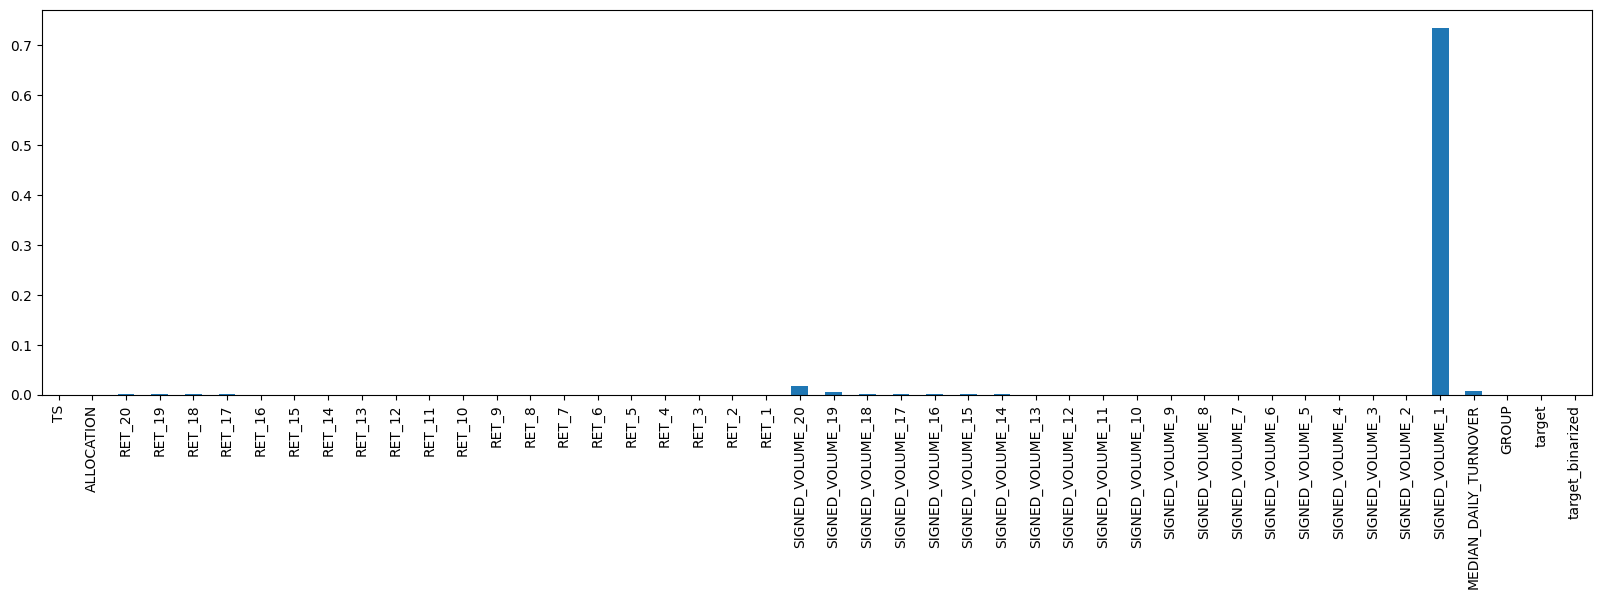

In [6]:
train_df.isna().mean().plot(kind="bar")

c'est stable dans le train / test et entre allocations 

<Axes: xlabel='ALLOCATION'>

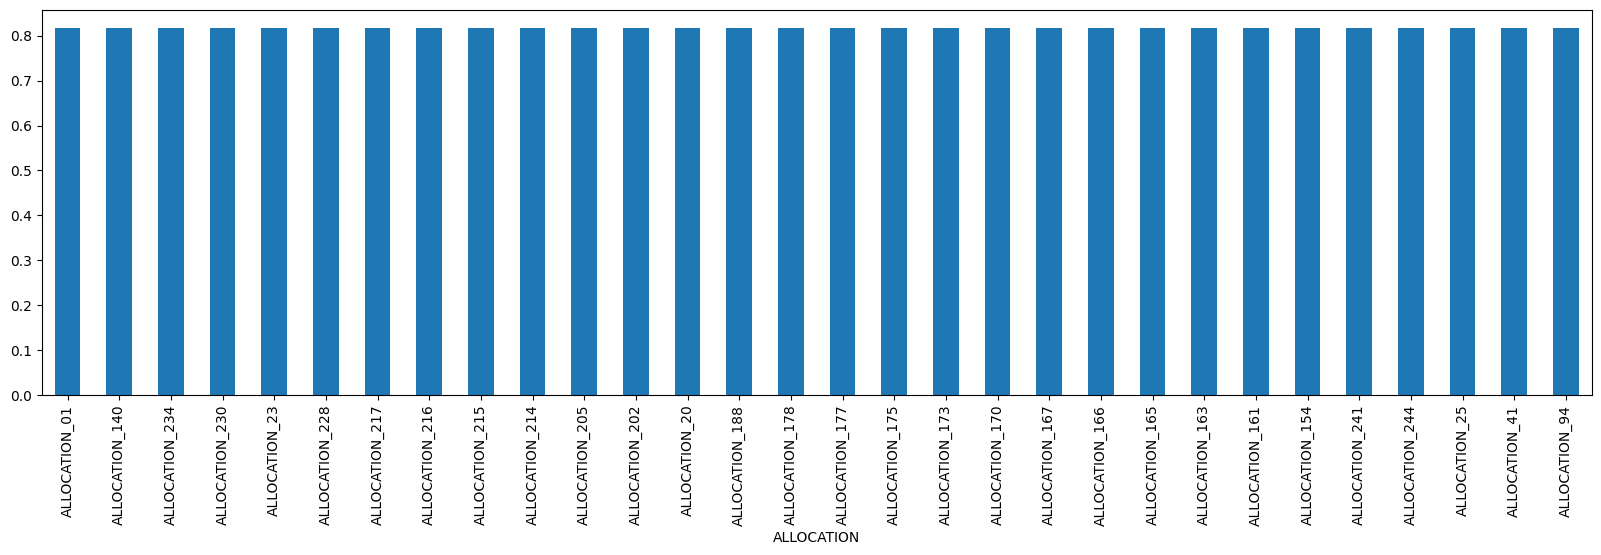

In [7]:
train_df.groupby("ALLOCATION")["SIGNED_VOLUME_1"].apply(lambda group : group.isna().mean()).sort_values(ascending=False).head(30).plot(kind="bar")

<Axes: >

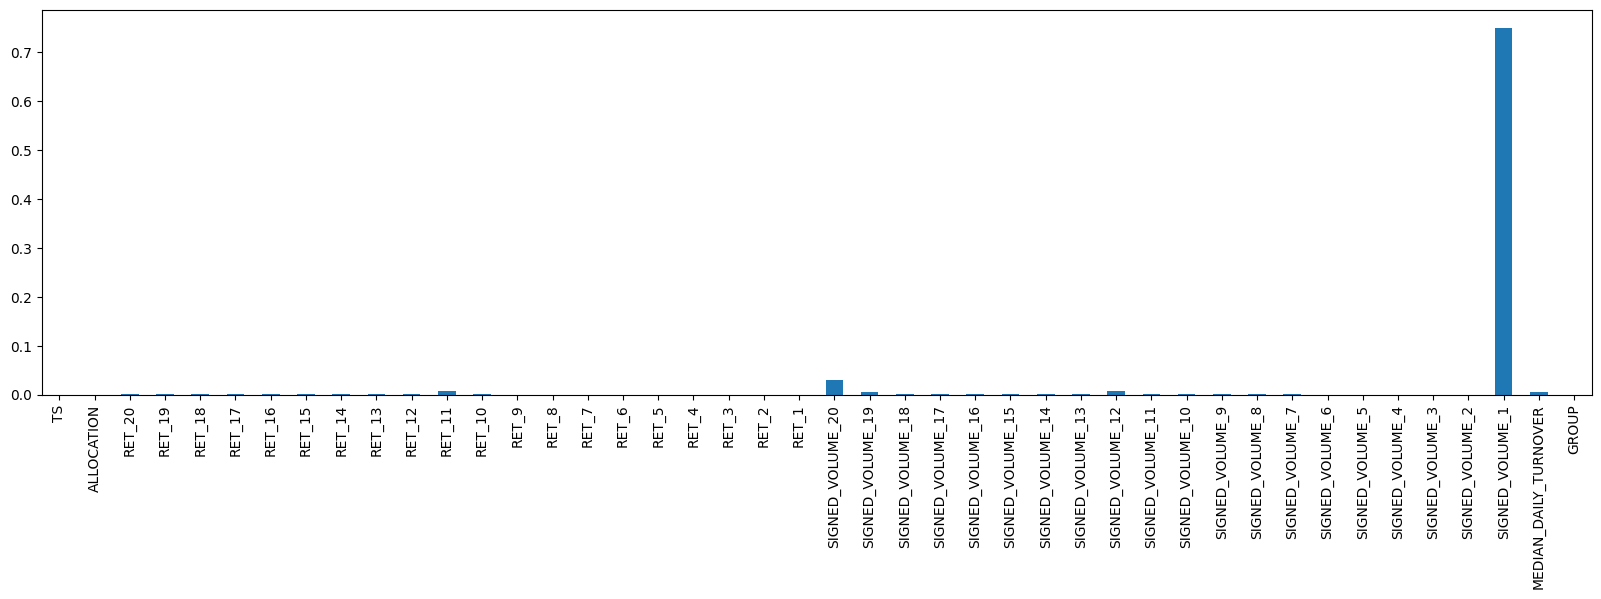

In [8]:
test_df.isna().mean().plot(kind="bar")

In [9]:
print(
    "TRAIN:\n"
    f"  unique dates: {train_df.TS.nunique()}\n"
    f"  unique allocations: {train_df.ALLOCATION.nunique()}\n"
    f"  shape: {train_df.shape}\n"
    "\nTEST:\n"
    f"  unique dates: {test_df.TS.nunique()}\n"
    f"  unique allocations: {test_df.ALLOCATION.nunique()}\n"
    f"  shape: {test_df.shape}"
)

TRAIN:
  unique dates: 2522
  unique allocations: 278
  shape: (527073, 46)

TEST:
  unique dates: 120
  unique allocations: 278
  shape: (31870, 44)


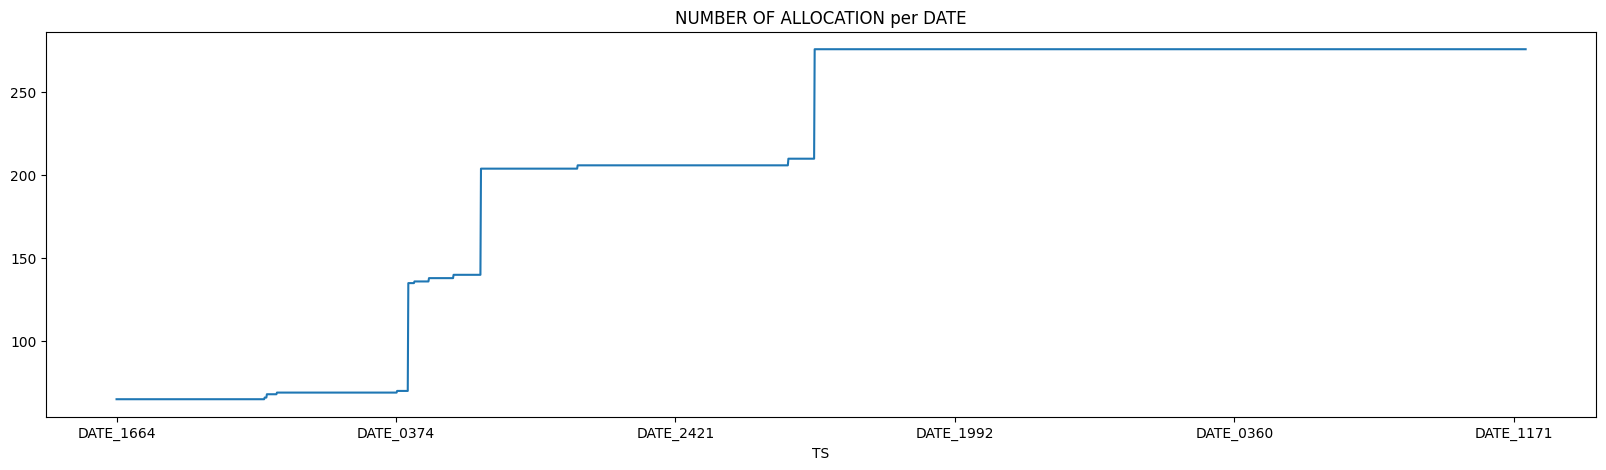

TS
DATE_1664     65
DATE_1942     65
DATE_1939     65
DATE_1172     65
DATE_2325     65
DATE_1141    276
DATE_1139    276
DATE_1137    276
DATE_1132    276
DATE_2522    276
Name: count, dtype: int64

In [12]:
fig, ax = plt.subplots()
ax.set_title("NUMBER OF ALLOCATION per DATE")
train_df.TS.value_counts(ascending=True).plot(ax=ax)
plt.show()

pd.concat(
    (train_df.TS.value_counts(ascending=True).head(5), train_df.TS.value_counts(ascending=True).tail(5))
)


les effects allocation peuvent etre surappris a cause de la repartition 

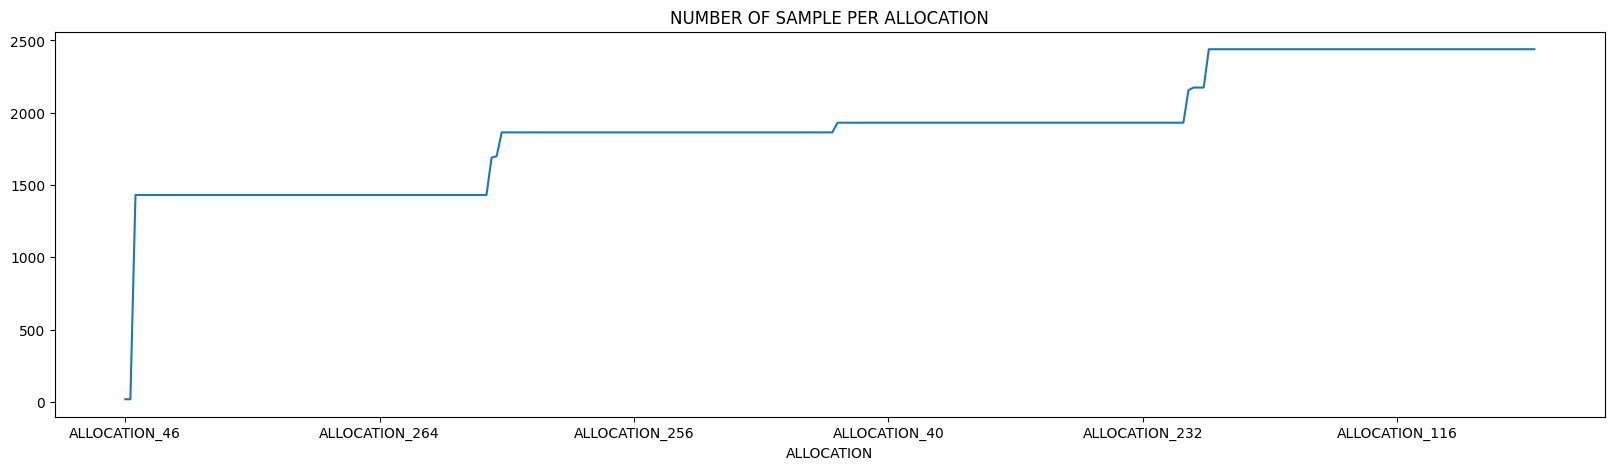

In [13]:
fig, ax = plt.subplots()
train_df.ALLOCATION.value_counts(ascending=True).plot(ax=ax)
ax.set_title("NUMBER OF SAMPLE PER ALLOCATION")
plt.show()

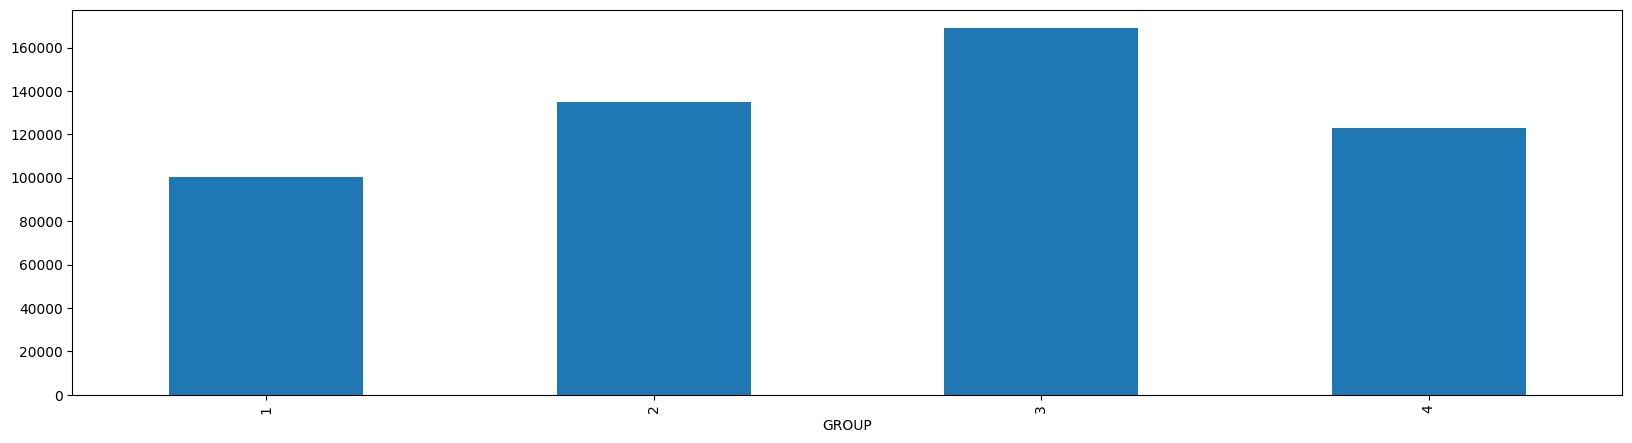

In [301]:
fig, ax = plt.subplots()
train_df.groupby("GROUP")["ALLOCATION"].count().plot(kind="bar", ax=ax)
plt.show()

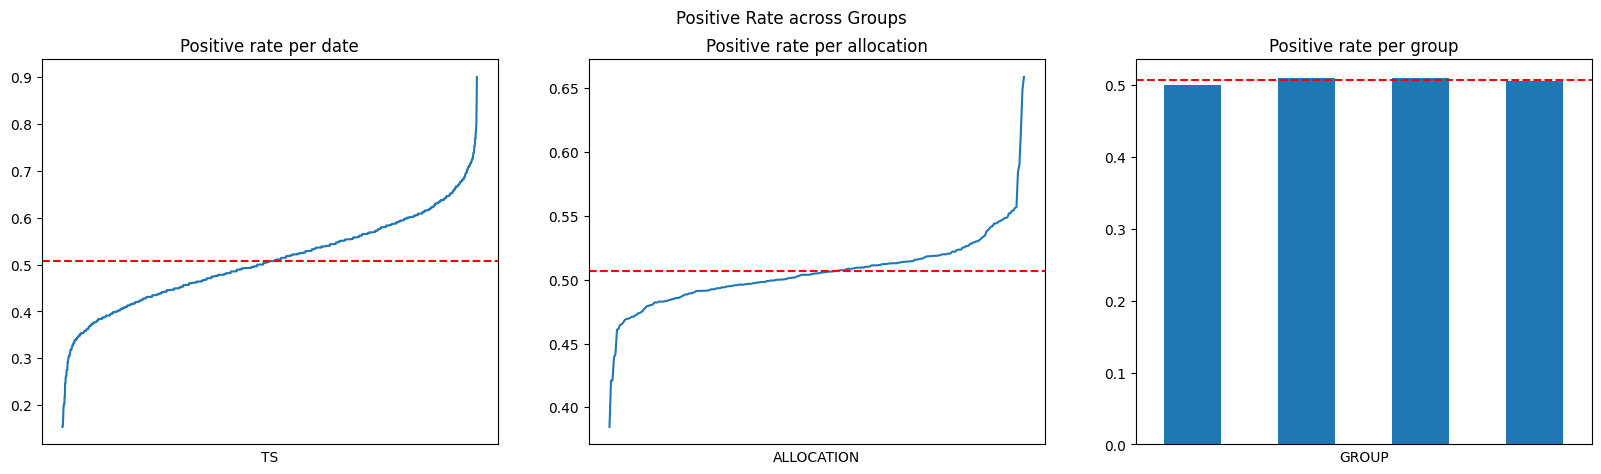

In [85]:
positive_rate = train_df.target_binarized.mean()
fig, ax = plt.subplots(1, 3)
fig.suptitle("Positive Rate across Groups")
train_df.groupby("TS")["target_binarized"].mean().sort_values().plot(ax=ax[0])
train_df.groupby("ALLOCATION")["target_binarized"].mean().sort_values().plot(ax=ax[1])
train_df.groupby("GROUP")["target_binarized"].mean().plot(kind="bar", ax=ax[2])

titles = [
    "Positive rate per date",
    "Positive rate per allocation",
    "Positive rate per group",
]

for i in range(3):
    ax[i].axhline(positive_rate, linestyle="--", color="r")
    ax[i].set_title(titles[i])
    ax[i].set_xticks([])
plt.show()

In [24]:
# fig, ax = plt.subplots()

# train_df.assign(positive_ret_1=lambda x : (x["RET_1"] > 0).astype(int)).groupby("ALLOCATION")["positive_ret_1"].mean()[train_df.groupby("ALLOCATION")["target_binarized"].mean().sort_values().index].plot(ax=ax)
# train_df.groupby("ALLOCATION")["target_binarized"].mean().sort_values().plot(ax=ax, label="future")
# ax.legend()
# plt.show()


# IMPLICATION FOR UNCERTAINTY MEASUREMENT 

When we compute the accuracy we need to account for the fact that groups of observations belong to the same dates. 
We model out of sample accuracy by 

$A_t = \mu + u_t + e_t$  

Where $\mu$ is the population accuracy (for a given model) $u_t$ the date (regime / market state) effect $e_t$ the intradate measurement error

$SE(A_t) = \frac{1}{\sqrt{D}} \sqrt{\tau^2 + \frac{p(1-p)}{\bar{n}}}$

where $\tau^2$ is the variance of $u_t$ and $\bar{n} = N / D$

In [14]:
def std_err_panel(D, n, tau, p):
    return np.sqrt(tau**2/D + (p - p ** 2)/(D * n))

In [324]:
naive_se = train_df.target_binarized.std() / np.sqrt(len(train_df))
D = train_df.TS.unique().shape[0]
n = train_df.ALLOCATION.unique().shape[0]
std_mean_acc_date = train_df.groupby("TS")["target_binarized"].mean().std()
p = train_df.target_binarized.mean()
se = std_mean_acc_date / np.sqrt(D)

print(
    f"Naive standard error {naive_se:4f}\n"
    f"Unique dates: {D}\n"
    f"Unique allocations: {n}\n"
    f"Stdev of accuracy per date: {std_mean_acc_date**2:4f}\n"
    f"Accuracy: {p:4f}\n"
    f"Standard Error: {se:4f}\n"
)

Naive standard error 0.000689
Unique dates: 2522
Unique allocations: 278
Stdev of accuracy per date: 0.009211
Accuracy: 0.507184
Standard Error: 0.001911



# DISTRIBUTION

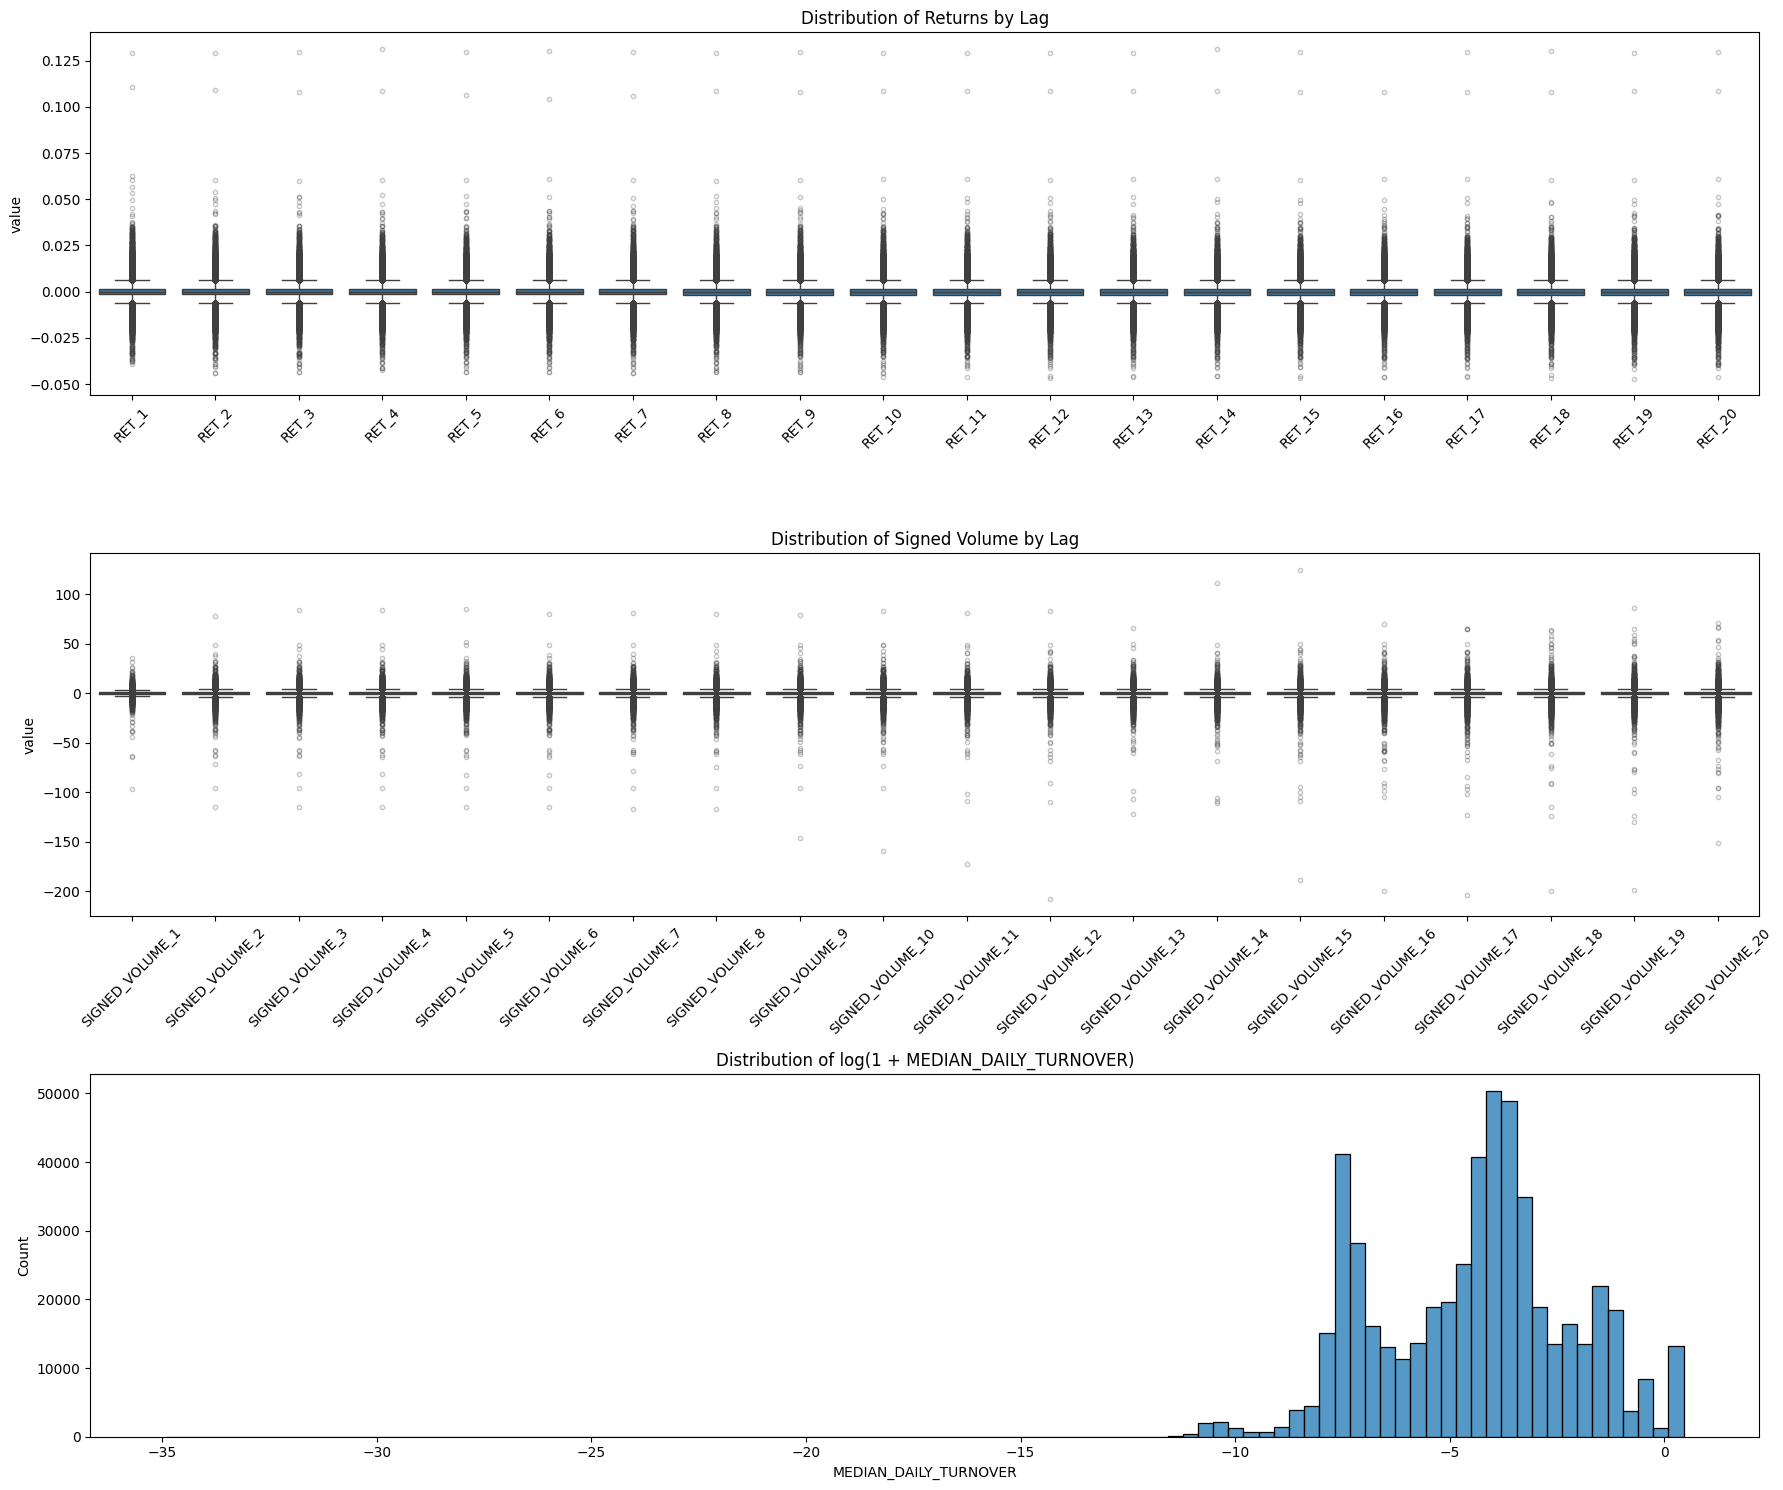

In [157]:
ret_cols = [f"RET_{i}" for i in range(1, 21)]
vol_cols = [f"SIGNED_VOLUME_{i}" for i in range(1, 21)]

fig, axes = plt.subplots(3, 1, figsize=(18, 15))

train_df[ret_cols].melt(var_name="lag", value_name="value").pipe( # long df pour seaborn 
    lambda d: sns.boxplot(data=d, x="lag", y="value", ax=axes[0], 
                          order=ret_cols, flierprops={"marker": ".", "alpha": 0.3})
)
axes[0].set_title("Distribution of Returns by Lag")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=45)

# Signed Volume
train_df[vol_cols].melt(var_name="lag", value_name="value").pipe(
    lambda d: sns.boxplot(data=d, x="lag", y="value", ax=axes[1],
                          order=vol_cols, flierprops={"marker": ".", "alpha": 0.3})
)
axes[1].set_title("Distribution of Signed Volume by Lag")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=45)

# Turnover
sns.histplot(
    train_df["MEDIAN_DAILY_TURNOVER"].apply(np.log), 
    bins=100, ax=axes[2]
)
axes[2].set_title("Distribution of log(1 + MEDIAN_DAILY_TURNOVER)")

plt.tight_layout()
plt.show()

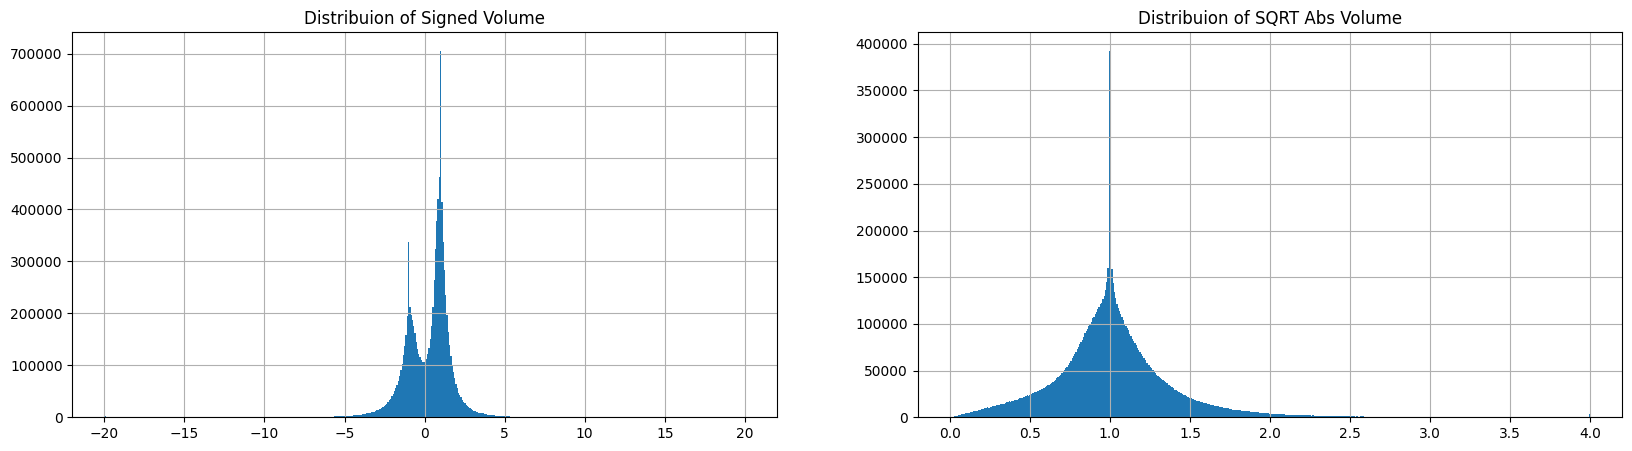

In [332]:
fig, ax = plt.subplots(1,2)
ax[0].set_title("Distribuion of Signed Volume")
train_df.melt(value_vars=vol_cols)["value"].clip(-20, 20).hist(bins=500, ax=ax[0])

ax[1].set_title("Distribuion of SQRT Abs Volume")
train_df.melt(value_vars=vol_cols)["value"].abs().apply(np.sqrt).clip(-4, 4).hist(bins=500, ax=ax[1])
plt.show()

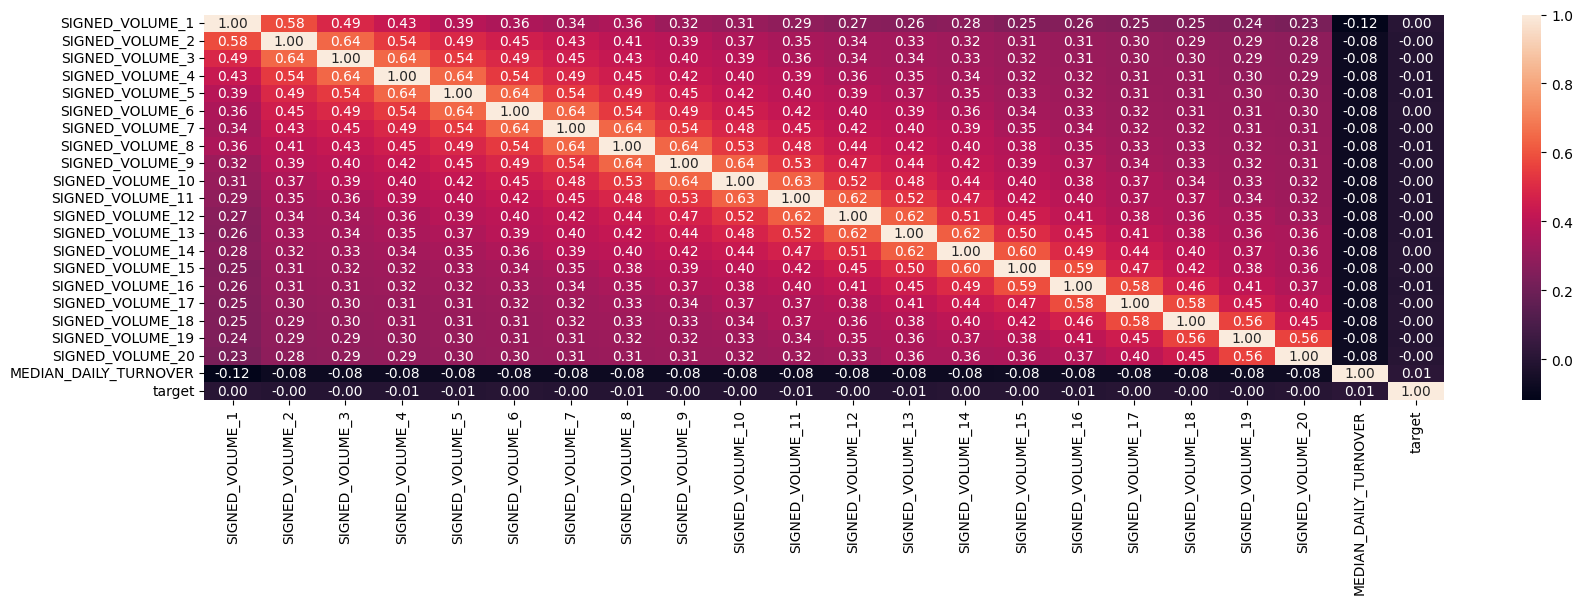

In [333]:
vol_cols = [f"SIGNED_VOLUME_{i}" for i in range(1, 21)]
fig, ax = plt.subplots()
sns.heatmap(train_df[[*vol_cols, "MEDIAN_DAILY_TURNOVER", "target"]].corr(), annot=True, fmt=".2f", ax=ax)
plt.show()

<Axes: >

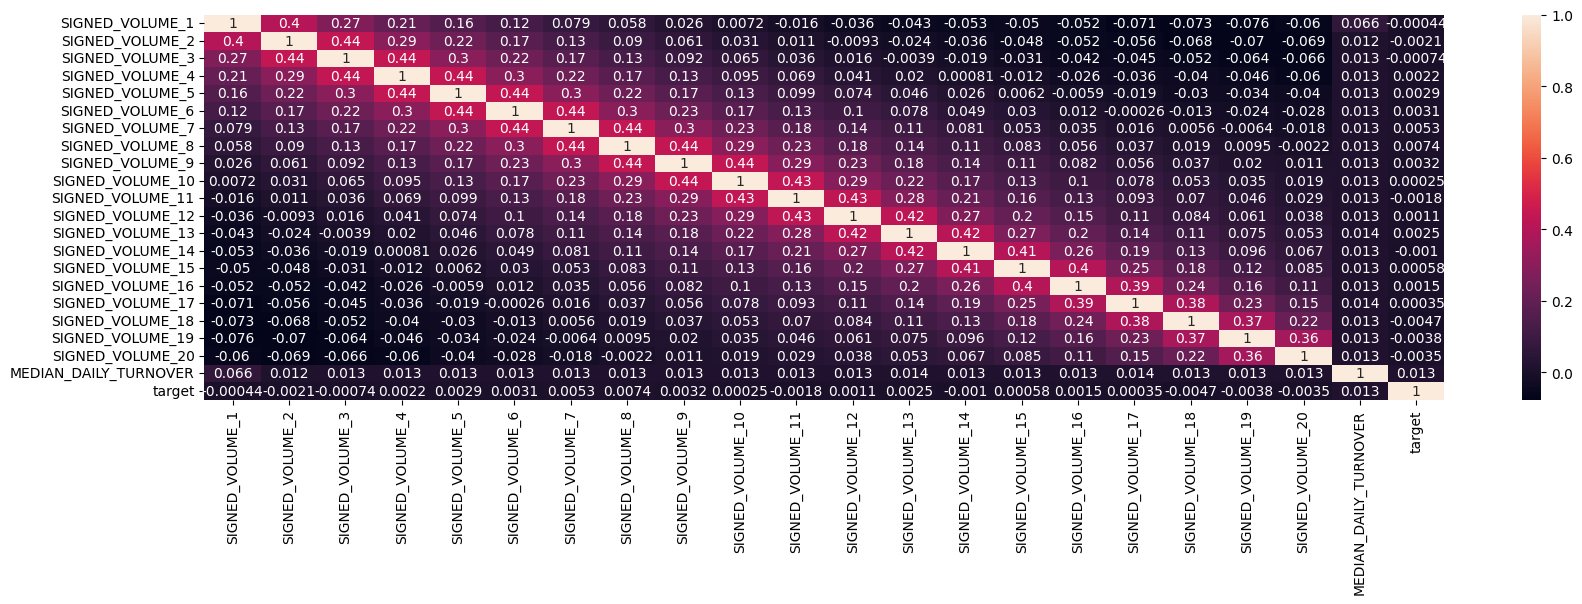

In [13]:
df_abs_sqrt_sv = pd.concat((train_df.pipe(lambda x : x[vol_cols].abs().pow(0.5)), train_df["MEDIAN_DAILY_TURNOVER"], train_df["target"]), axis=1)
sns.heatmap(df_abs_sqrt_sv.corr(), annot=True)

<Axes: >

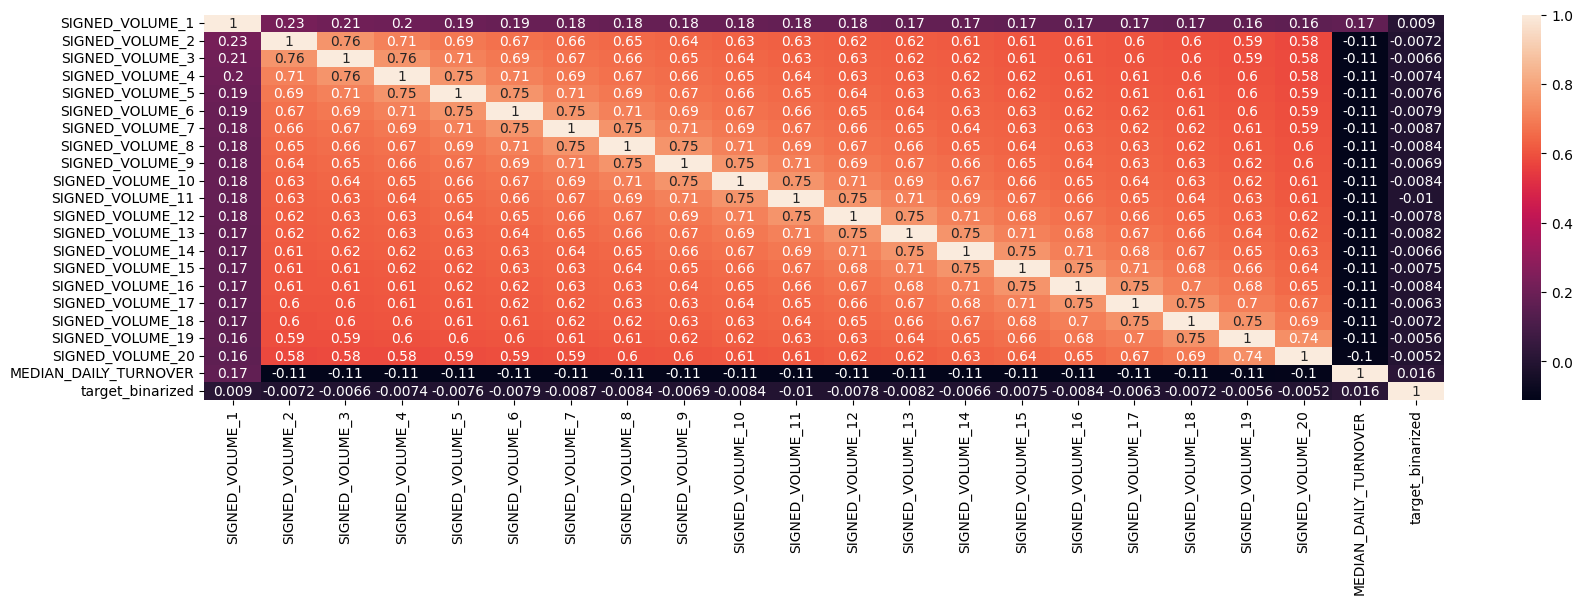

In [9]:
df_abs_sqrt_sv = pd.concat((train_df.pipe(lambda x : (x[vol_cols] > 0)), train_df["MEDIAN_DAILY_TURNOVER"], train_df["target_binarized"]), axis=1)
sns.heatmap(df_abs_sqrt_sv.corr(), annot=True)

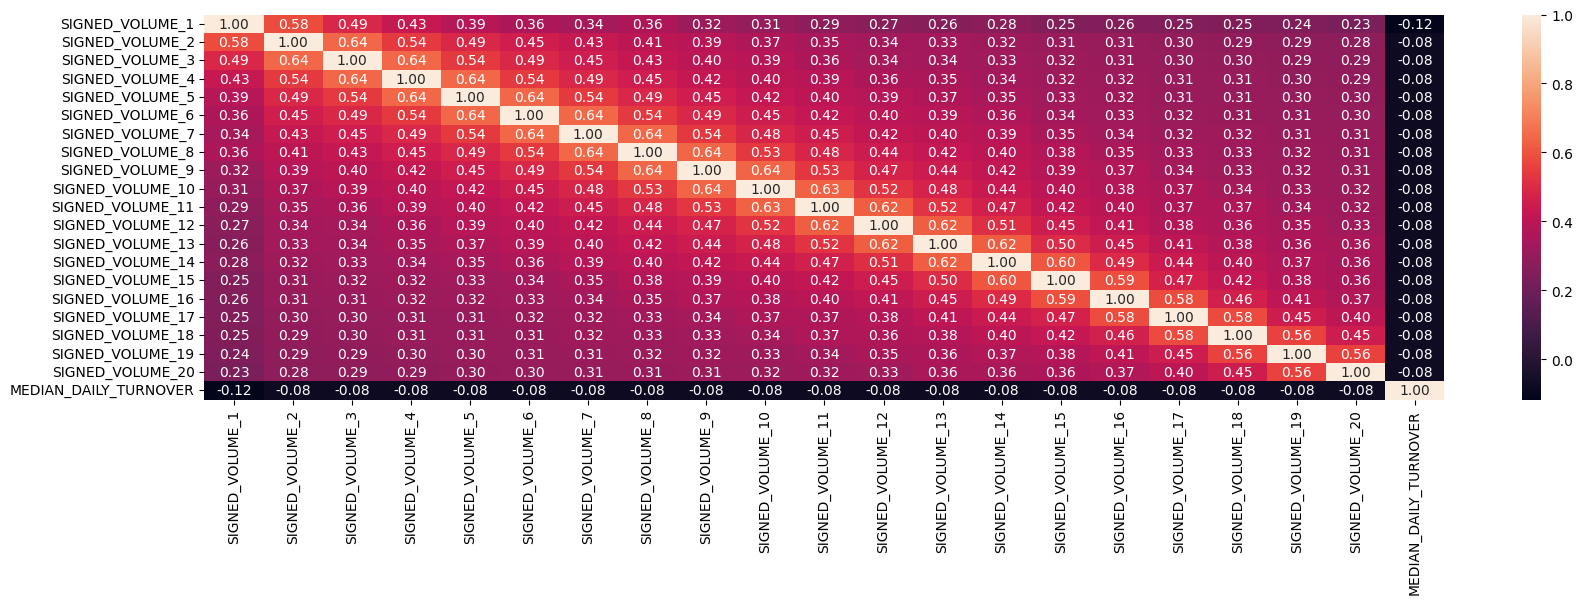

In [ ]:
vol_cols = [f"SIGNED_VOLUME_{i}" for i in range(1, 21)]
fig, ax = plt.subplots()
sns.heatmap(train_df[[*vol_cols, "MEDIAN_DAILY_TURNOVER"]].corr(), annot=True, fmt=".2f", ax=ax)
plt.show()

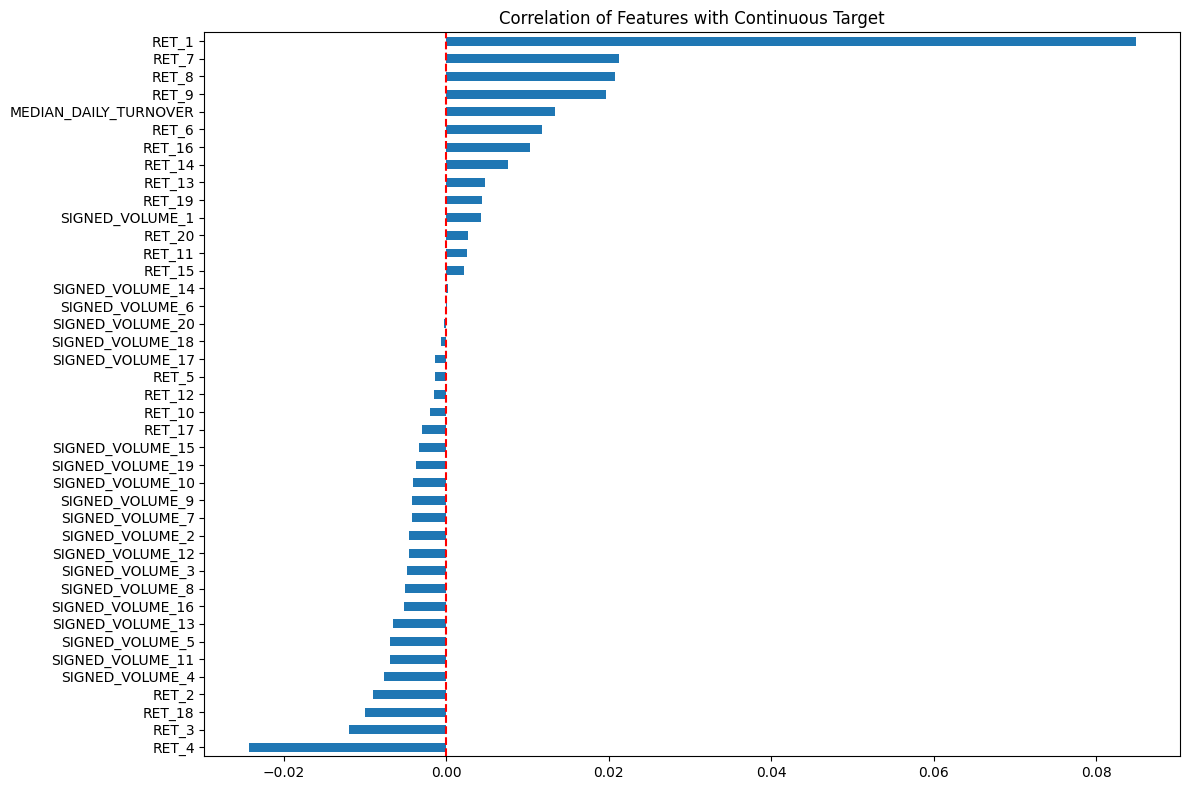

In [11]:
ret_cols = [f"RET_{i}" for i in range(1, 21)]
vol_cols = [f"SIGNED_VOLUME_{i}" for i in range(1, 21)]

all_feature_cols = ret_cols + vol_cols + ["MEDIAN_DAILY_TURNOVER"]
corr = train_df[all_feature_cols].corrwith(train_df["target"]).sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
corr.plot(kind="barh", ax=ax)
ax.axvline(0, color="red", linestyle="--")
ax.set_title("Correlation of Features with Continuous Target")
plt.tight_layout()
plt.show()

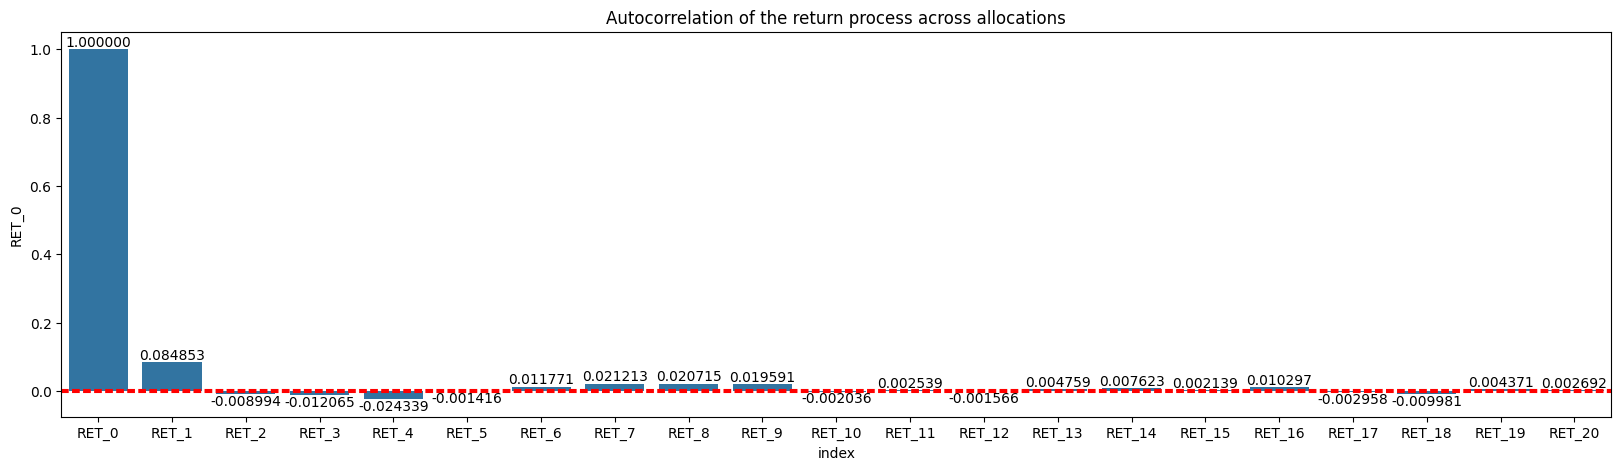

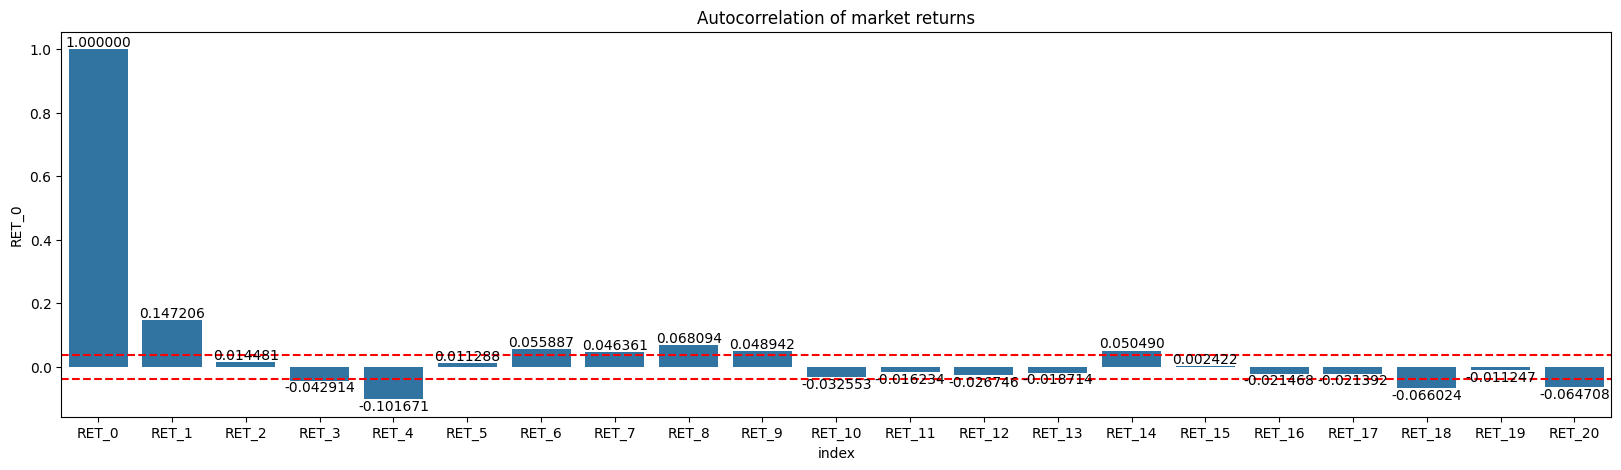

In [139]:
groupers = ["TS", "ALLOCATION", "GROUP"]
ret_cols = [f"RET_{i}" for i in range(1, 21)]


df_for_autocorr = train_df[["target", *ret_cols, *groupers]].rename(columns={"target":"RET_0"}).set_index(groupers, drop=True)
autocorr = df_for_autocorr.corr().loc["RET_0"].reset_index()

fig, ax = plt.subplots()
ax.set_title("Autocorrelation of the return process across allocations")
ax = sns.barplot(autocorr, x="index", y="RET_0",ax=ax)
ax.bar_label(ax.containers[0], fontsize=10, fmt="{:2f}")
ax.axhline(y=1.96 / train_df.shape[0] ** 0.5, c="r", linestyle="--") # naive white noise error bar do we really have so many observations ? 
ax.axhline(y=-1.96 / train_df.shape[0] ** 0.5, c="r", linestyle="--")
plt.show()

market_autocorr = train_df.set_index(groupers).groupby("TS")[["target", *ret_cols]].mean().rename(columns={"target":"RET_0"}).corr().loc["RET_0"].reset_index()

fig, ax = plt.subplots()
ax.set_title("Autocorrelation of market returns")
ax = sns.barplot(market_autocorr, x="index", y="RET_0",ax=ax)
ax.bar_label(ax.containers[0], fontsize=10, fmt="{:2f}")
ax.axhline(y=1.96 / train_df.TS.unique().shape[0] ** 0.5, c="r", linestyle="--") # naive white noise error bar do we really have so many observations ? 
ax.axhline(y=-1.96 / train_df.TS.unique().shape[0] ** 0.5, c="r", linestyle="--")
plt.show()

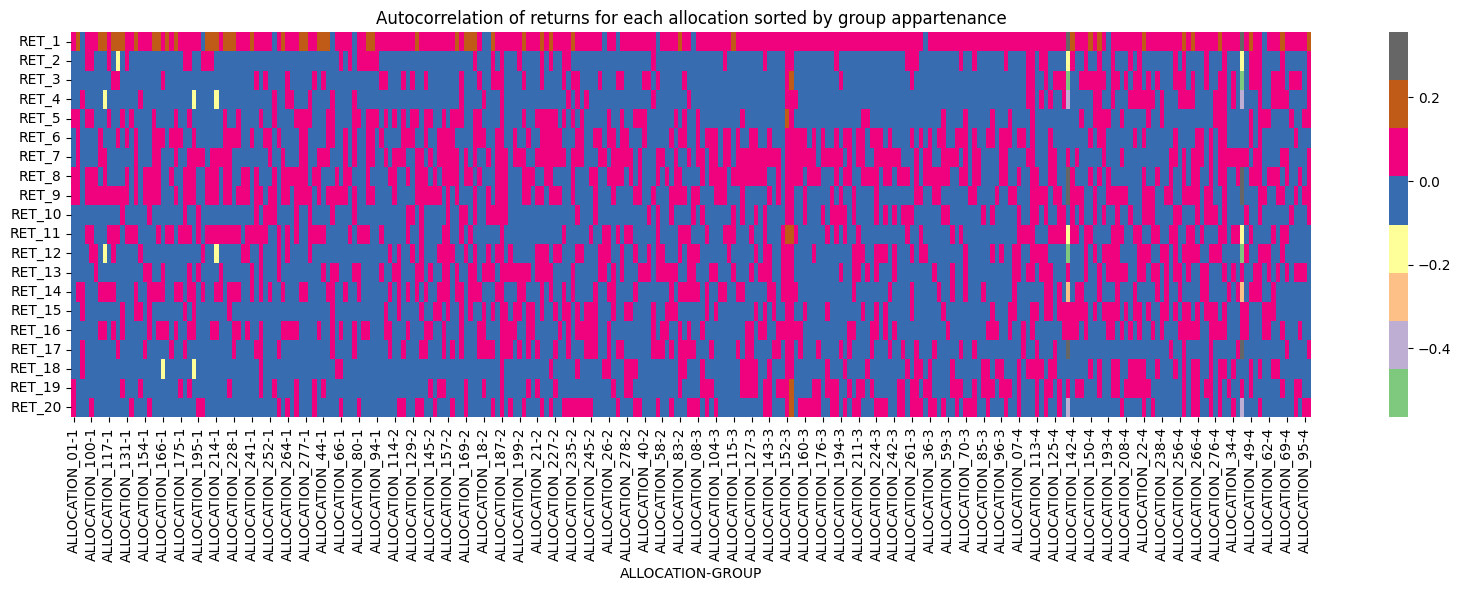

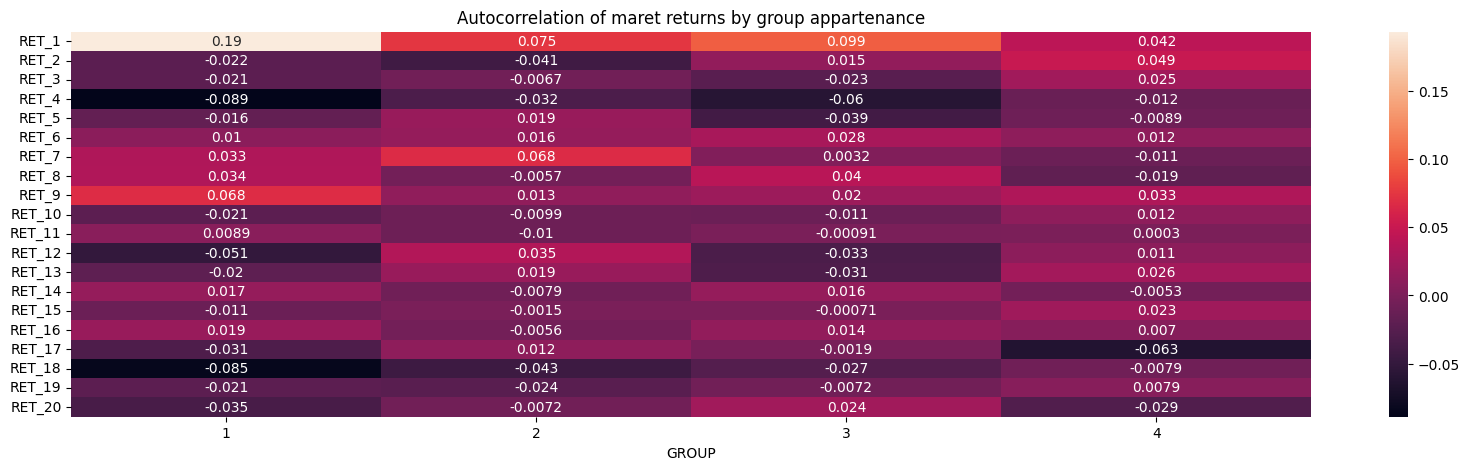

In [ ]:
autocorrelation_per_alloc = df_for_autocorr.groupby(["ALLOCATION", "GROUP"]).corr().T.xs(axis=1, level=2, key="RET_0").iloc[1:].sort_index(axis=1, level=1)

fig, ax = plt.subplots()
ax.set_title("Autocorrelation of returns for each allocation sorted by group appartenance")
sns.heatmap(autocorrelation_per_alloc, cmap="Accent", ax=ax)

fig, ax = plt.subplots()
ax.set_title("Autocorrelation of market returns by group appartenance")
sns.heatmap(train_df.set_index(groupers).groupby(["TS", "GROUP"])[["target", *ret_cols]].mean().rename(columns={"target":"RET_0"}).groupby("GROUP").corr().xs(level=1, key="RET_0").T.iloc[1:],
            annot=True)
plt.show()

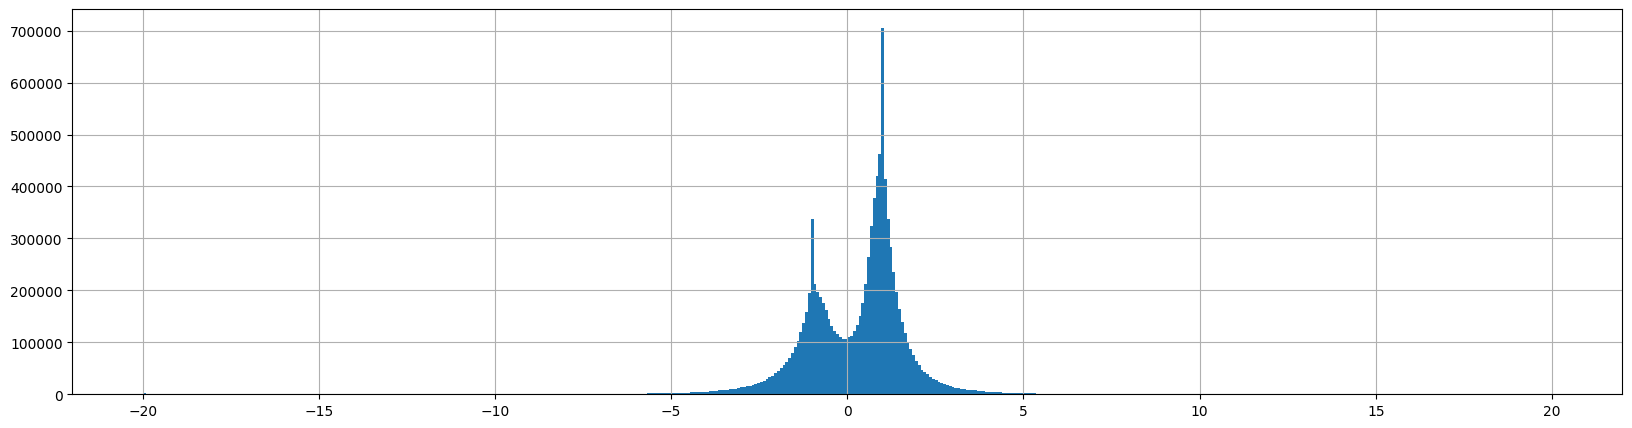

In [ ]:
df_for_autocorr

In [219]:
def plot_conditional_mean(
    x,
    y,
    n_bins=20,
    quantile_bins=True,
    show_ci=True,
    ax=None,
):
    df = pd.DataFrame({"x": x, "y": y}).dropna()

    if quantile_bins:
        df["bin"] = pd.qcut(df["x"], q=n_bins, duplicates="drop")
    else:
        df["bin"] = pd.cut(df["x"], bins=n_bins)

    stats = (
        df.groupby("bin", observed=True)
        .agg(
            x_mean=("x", "mean"),
            y_mean=("y", "mean"),
            y_std=("y", "std"),
            count=("y", "size"),
        )
        .reset_index()
    )

    stats["y_se"] = stats["y_std"] / np.sqrt(stats["count"])
    stats["ci_95"] = 1.96 * stats["y_se"]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    if show_ci:
        ax.errorbar(
            stats["x_mean"],
            stats["y_mean"],
            yerr=stats["ci_95"],
            fmt="o-",
            capsize=3,
        )
    else:
        ax.plot(stats["x_mean"], stats["y_mean"], "o-")

    ax.axhline(df["y"].mean(), linestyle="--", alpha=0.5)
    ax.set_xlabel(r"$\mathbb{E}[X \mid X \in B_k]$")
    ax.set_ylabel(r"$\mathbb{E}[Y \mid X \in B_k]$")
    ax.set_title("Empirical conditional mean")
    ax.grid(alpha=0.3)

    return stats, ax

# distribution feature drift ? 

In [ ]:
all_feature_cols = ret_cols + vol_cols + ["MEDIAN_DAILY_TURNOVER"]

results = []
for col in all_feature_cols:
    train_vals = train_df[col].dropna()
    test_vals = test_df[col].dropna()
    stat, pvalue = ks_2samp(train_vals, test_vals)
    results.append({"feature": col, "ks_stat": stat, "pvalue": pvalue})

drift_df = pd.DataFrame(results).sort_values("ks_stat", ascending=False)
drift_df

,feature,ks_stat,pvalue
20,SIGNED_VOLUME_1,0.038178,5.727844e-10
40,MEDIAN_DAILY_TURNOVER,0.037774,1.624785e-37
29,SIGNED_VOLUME_10,0.034708,6.951792e-32
25,SIGNED_VOLUME_6,0.033135,4.206937e-29
26,SIGNED_VOLUME_7,0.032822,1.466102e-28
21,SIGNED_VOLUME_2,0.032432,6.731954e-28
12,RET_13,0.032006,3.541627e-27
22,SIGNED_VOLUME_3,0.031753,9.278375e-27
27,SIGNED_VOLUME_8,0.030886,2.439148e-25
24,SIGNED_VOLUME_5,0.030289,2.185951e-24


rmq: with 500k observation, ks test is too strong, so pval detects any tiny diff, but stat is small so ok, no practical drift 

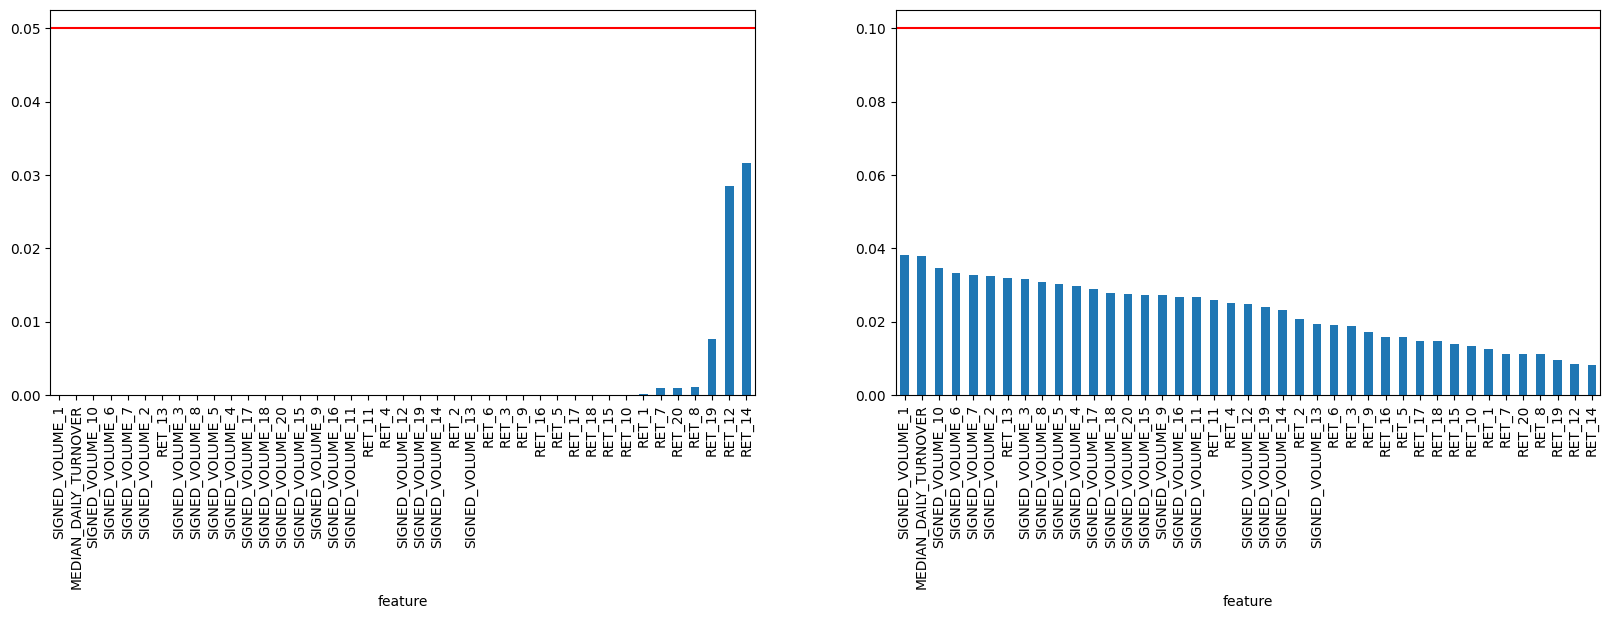

In [69]:
_, ax = plt.subplots(1, 2, figsize=(20, 5))
drift_df.set_index("feature").pvalue.plot(kind="bar", ax=ax[0])
ax[0].axhline(0.05, color="red")
drift_df.set_index("feature").ks_stat.plot(kind="bar", ax=ax[1])
ax[1].axhline(0.1, color="red")
plt.show()

# Peu de signal ...

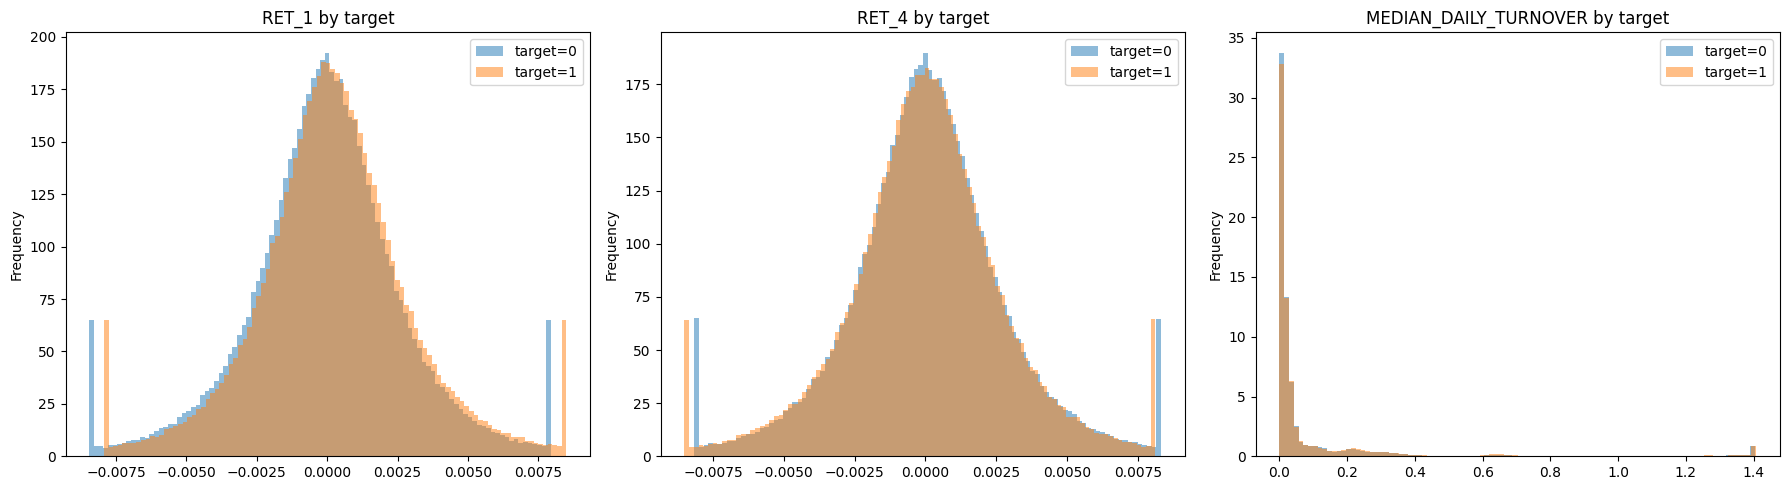

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["RET_1", "RET_4", "MEDIAN_DAILY_TURNOVER"]):
    for label, group in train_df.groupby("target_binarized")[col]:
        group.clip(*group.quantile([0.01, 0.99])).plot(
            kind="hist", bins=100, alpha=0.5, ax=ax, label=label, density=True
        )
    ax.set_title(f"{col} by target")
    ax.legend(["target=0", "target=1"])

plt.tight_layout()
plt.show()

/var/folders/7y/q7t39mvn5hg58w28jd27zdx80000gn/T/ipykernel_1630/189404149.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc_by_date = train_df.groupby("TS").apply(


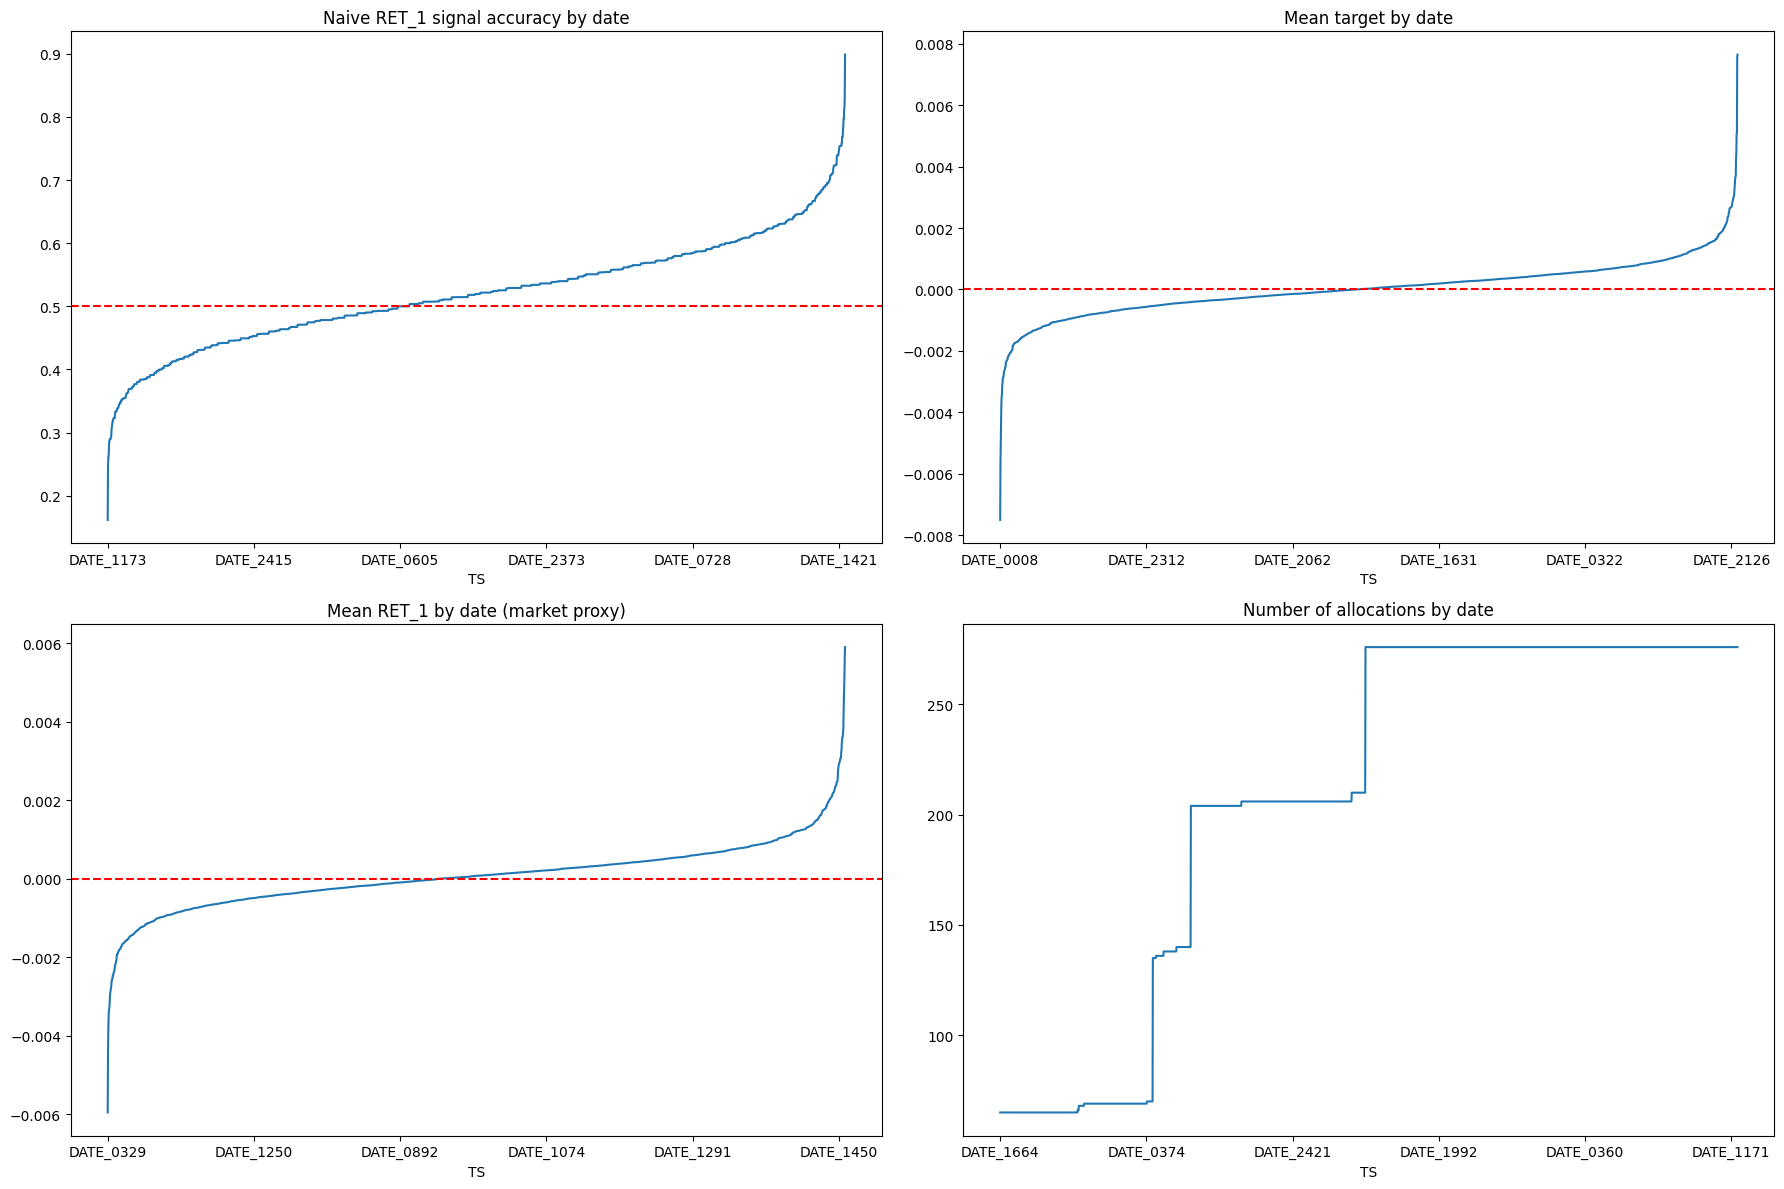

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Accuracy par date : signal debile ou on predit 1 si RET_1 > median(RET_1)
acc_by_date = train_df.groupby("TS").apply(
    lambda x: (x["target_binarized"] == (x["RET_1"] > x["RET_1"].median())).mean()
)
acc_by_date.sort_values().plot(ax=axes[0, 0])
axes[0, 0].axhline(0.5, color="red", linestyle="--")
axes[0, 0].set_title("Naive RET_1 signal accuracy by date")

# Mean target par date
train_df.groupby("TS")["target"].mean().sort_values().plot(ax=axes[0, 1])
axes[0, 1].axhline(0, color="red", linestyle="--")
axes[0, 1].set_title("Mean target by date")

# Mean RET_1 par date
train_df.groupby("TS")["RET_1"].mean().sort_values().plot(ax=axes[1, 0])
axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_title("Mean RET_1 by date (market proxy)")

# Nb allocations par date
train_df.groupby("TS").size().sort_values().plot(ax=axes[1, 1])
axes[1, 1].set_title("Number of allocations by date")

plt.tight_layout()
plt.show()

# y a pas de truc facile pour predire les dates difficiles 

In [40]:
date_stats = pd.DataFrame({
    "mean_target": train_df.groupby("TS")["target"].mean(),
    "mean_ret1": train_df.groupby("TS")["RET_1"].mean(),
    "naive_accuracy": train_df.groupby("TS").apply(
        lambda x: (x["target_binarized"] == (x["RET_1"] > x["RET_1"].median())).mean()
    )
})

print(date_stats.corr())

                mean_target  mean_ret1  naive_accuracy
mean_target        1.000000   0.147206        0.021802
mean_ret1          0.147206   1.000000       -0.009344
naive_accuracy     0.021802  -0.009344        1.000000


/var/folders/7y/q7t39mvn5hg58w28jd27zdx80000gn/T/ipykernel_1630/2524210652.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "naive_accuracy": train_df.groupby("TS").apply(


In [41]:
date_stats["n_alloc"] = train_df.groupby("TS").size()
date_stats["ret1_std"] = train_df.groupby("TS")["RET_1"].std()
date_stats["ret1_dispersion"] = train_df.groupby("TS")["RET_1"].std() / train_df.groupby("TS")["RET_1"].mean().abs()

print(date_stats.corr()["naive_accuracy"].sort_values())

n_alloc           -0.107053
mean_ret1         -0.009344
mean_target        0.021802
ret1_dispersion    0.023961
ret1_std           0.081493
naive_accuracy     1.000000
Name: naive_accuracy, dtype: float64


In [42]:
# Sans neutralisation : long si RET_1 > 0
pred_raw = (train_df["RET_1"] > 0).astype(int)

# Avec neutralisation : long si RET_1 > médiane du jour
pred_neutralized = train_df.groupby("TS")["RET_1"].transform(
    lambda x: (x > x.median()).astype(int)
)

acc_raw = (pred_raw == train_df["target_binarized"]).groupby(train_df["TS"]).mean()
acc_neutralized = (pred_neutralized == train_df["target_binarized"]).groupby(train_df["TS"]).mean()

print(f"Raw accuracy: {acc_raw.mean():.4f} ± {acc_raw.std():.4f}")
print(f"Neutralized accuracy: {acc_neutralized.mean():.4f} ± {acc_neutralized.std():.4f}")

Raw accuracy: 0.5231 ± 0.0888
Neutralized accuracy: 0.5206 ± 0.0831


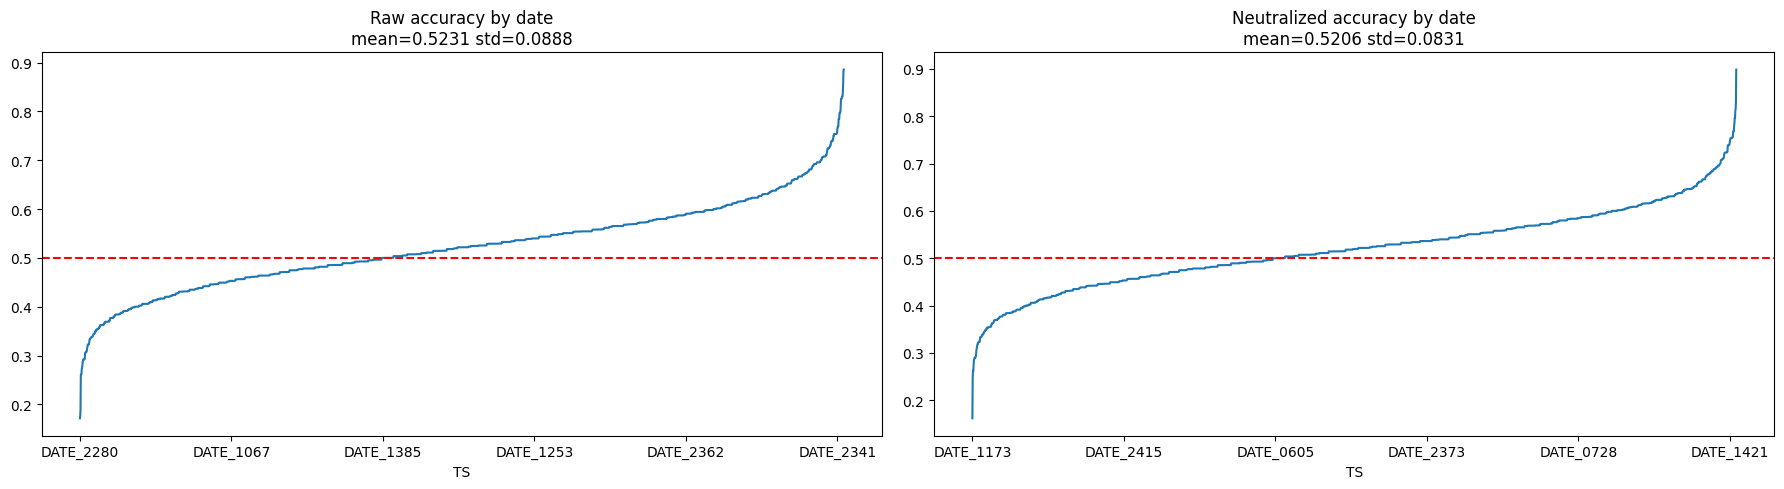

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

acc_raw.sort_values().plot(ax=axes[0])
axes[0].axhline(0.5, color="red", linestyle="--")
axes[0].set_title(f"Raw accuracy by date\nmean={acc_raw.mean():.4f} std={acc_raw.std():.4f}")

acc_neutralized.sort_values().plot(ax=axes[1])
axes[1].axhline(0.5, color="red", linestyle="--")
axes[1].set_title(f"Neutralized accuracy by date\nmean={acc_neutralized.mean():.4f} std={acc_neutralized.std():.4f}")

plt.tight_layout()
plt.show()

/var/folders/7y/q7t39mvn5hg58w28jd27zdx80000gn/T/ipykernel_1630/3687160295.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc_by_date = train_df.groupby("ALLOCATION").apply(


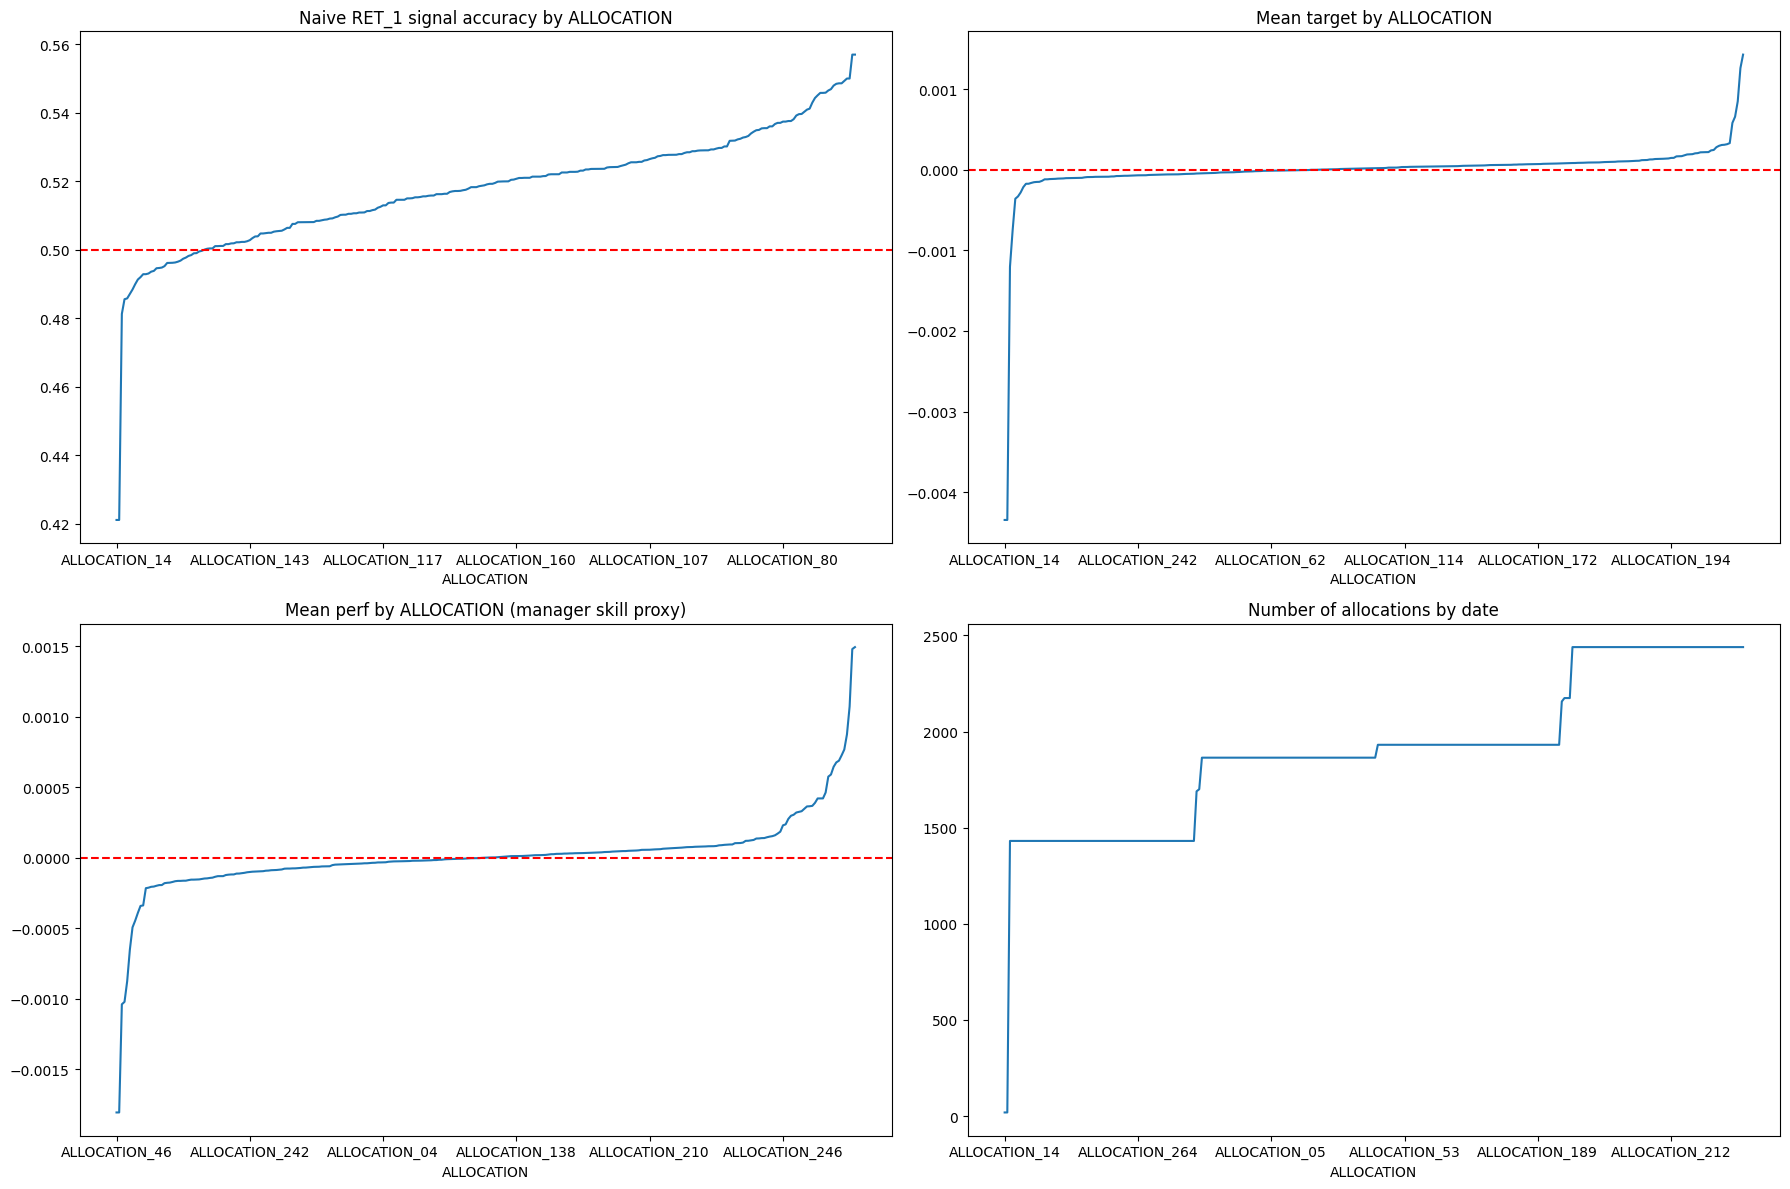

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Accuracy par date : signal debile ou on predit 1 si RET_1 > median(RET_1)
acc_by_date = train_df.groupby("ALLOCATION").apply(
    lambda x: (x["target_binarized"] == (x["RET_1"] > x["RET_1"].median())).mean()
)
acc_by_date.sort_values().plot(ax=axes[0, 0])
axes[0, 0].axhline(0.5, color="red", linestyle="--")
axes[0, 0].set_title("Naive RET_1 signal accuracy by ALLOCATION")

# Mean target par date
train_df.groupby("ALLOCATION")["target"].mean().sort_values().plot(ax=axes[0, 1])
axes[0, 1].axhline(0, color="red", linestyle="--")
axes[0, 1].set_title("Mean target by ALLOCATION")

# Mean RET_1 par date

train_df.assign(mean_perf=lambda df : df[ret_cols].mean(axis=1)).groupby("ALLOCATION")["mean_perf"].mean().sort_values().plot(ax=axes[1, 0])
axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_title("Mean perf by ALLOCATION (manager skill proxy)")

# Nb date par alolocation
train_df.groupby("ALLOCATION").size().sort_values().plot(ax=axes[1, 1])
axes[1, 1].set_title("Number of allocations by date")

plt.tight_layout()
plt.show()

- RET_1 est le signal dominant
- Signal très faible partout — distributions quasi identiques entre classes
- Pas de drift train/test
- Dates difficiles existent et ne s'expliquent pas facilement
- La neutralisation stabilise légèrement mais ne résout pas le problème fondamental (et encore)

In [45]:
alloc_stats = pd.DataFrame({
    "mean_target": train_df.groupby("ALLOCATION")["target"].mean(),
    "mean_ret1": train_df.groupby("ALLOCATION")["RET_1"].mean(),
    "naive_accuracy": acc_by_date
})
print(alloc_stats.corr())

                mean_target  mean_ret1  naive_accuracy
mean_target        1.000000   0.962932        0.393745
mean_ret1          0.962932   1.000000        0.443001
naive_accuracy     0.393745   0.443001        1.000000


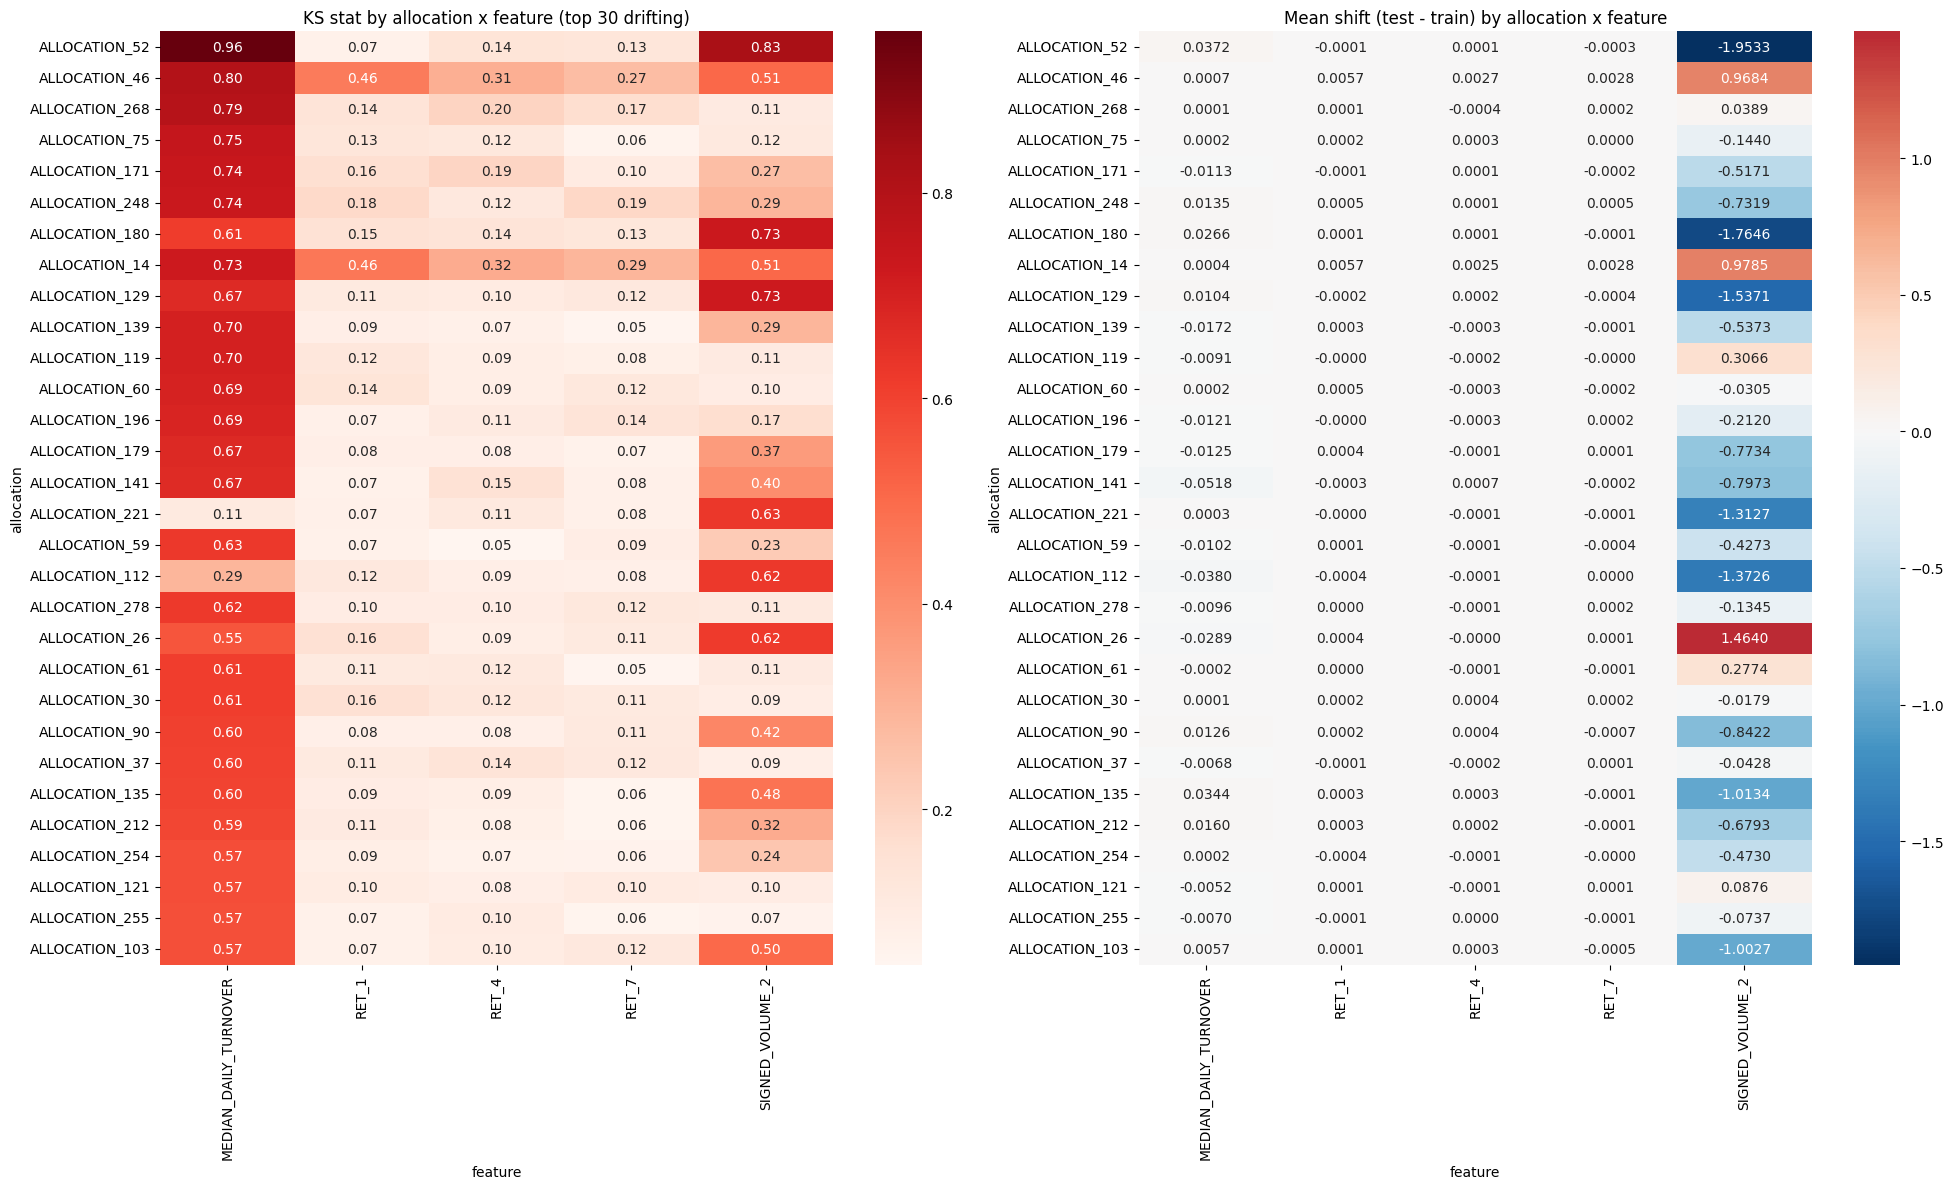

In [164]:
features_to_check = ["RET_1", "RET_4", "RET_7", "SIGNED_VOLUME_2", "MEDIAN_DAILY_TURNOVER"]

all_drift = []
for feat in features_to_check:
    for alloc in train_df["ALLOCATION"].unique():
        train_vals = train_df[train_df["ALLOCATION"] == alloc][feat].dropna()
        test_vals = test_df[test_df["ALLOCATION"] == alloc][feat].dropna()
        if len(train_vals) == 0 or len(test_vals) == 0:
            continue
        stat, pvalue = ks_2samp(train_vals, test_vals)
        all_drift.append({
            "feature": feat,
            "allocation": alloc,
            "ks_stat": stat,
            "mean_shift": (test_vals.mean() - train_vals.mean())
        })

drift_df = pd.DataFrame(all_drift)

fig, axes = plt.subplots(1, 2, figsize=(20, 12))

# Heatmap KS stat
ks_pivot = drift_df.pivot(index="allocation", columns="feature", values="ks_stat")
top_allocs = ks_pivot.max(axis=1).sort_values(ascending=False).head(30).index
sns.heatmap(
    ks_pivot.loc[top_allocs],
    annot=True, fmt=".2f", cmap="Reds",
    ax=axes[0]
)
axes[0].set_title("KS stat by allocation x feature (top 30 drifting)")

# Heatmap mean shift
shift_pivot = drift_df.pivot(index="allocation", columns="feature", values="mean_shift")
sns.heatmap(
    shift_pivot.loc[top_allocs],
    annot=True, fmt=".4f", cmap="RdBu_r", center=0,
    ax=axes[1]
)
axes[1].set_title("Mean shift (test - train) by allocation x feature")

plt.tight_layout()
plt.show()

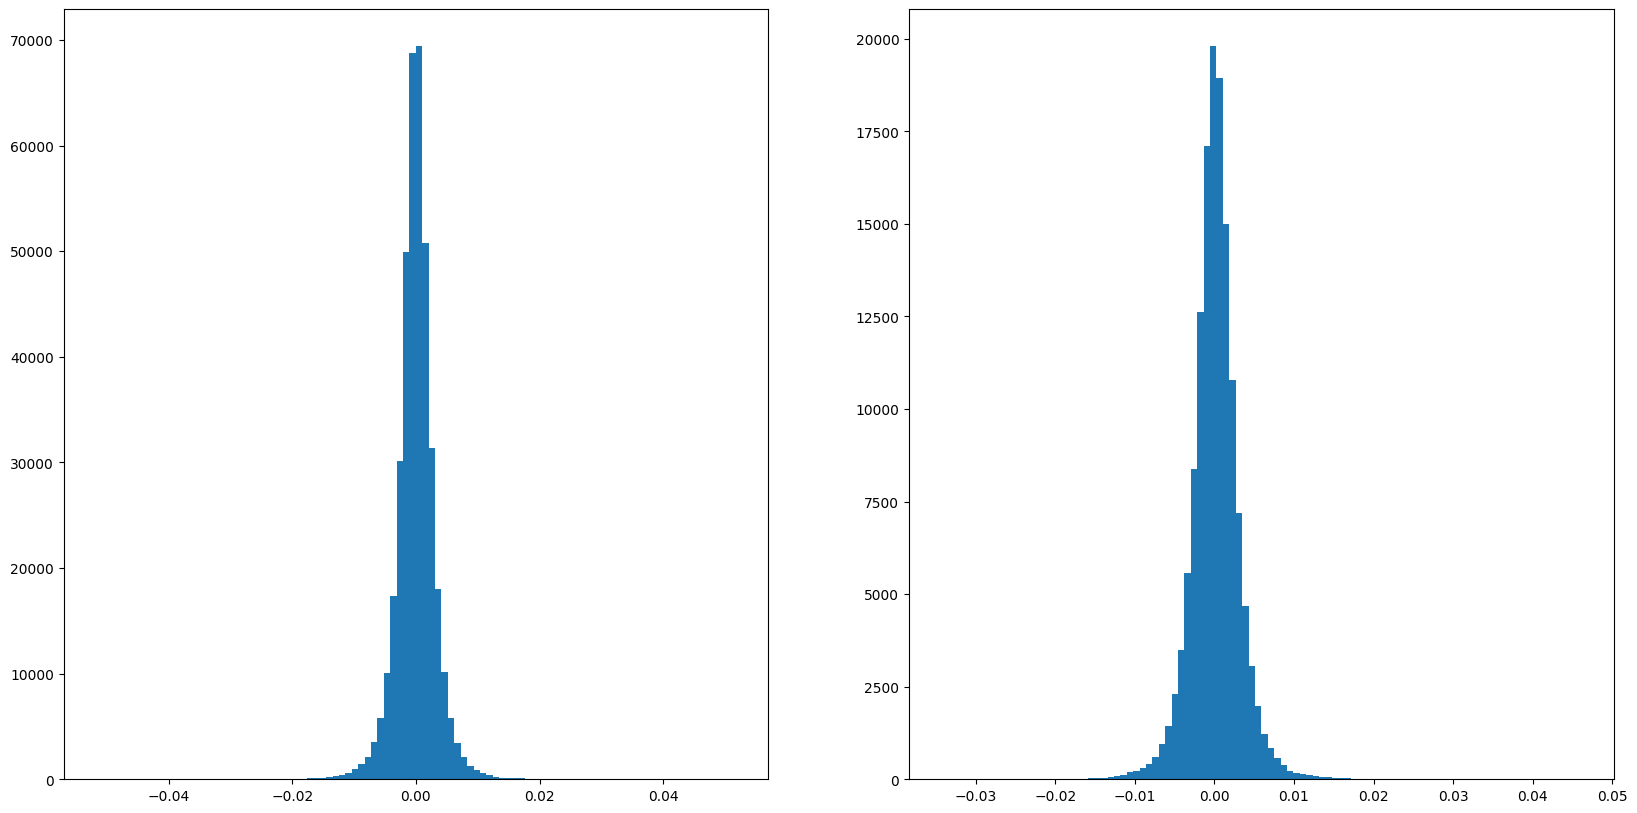

svna
0.0    0.040555
1.0    0.000862
dtype: float64

In [47]:
df = train_df[["SIGNED_VOLUME_1", "target", "target_binarized"]].assign(svna=train_df["SIGNED_VOLUME_1"].isna().astype(float))


na = df.loc[df["svna"]==1]
nonna = df.loc[df["svna"]==0]

stats = df.groupby("svna")["target"].agg(["mean", "median", "std", "skew"])

_, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].hist(na["target"], bins=100)
axes[1].hist(nonna["target"], bins=100)
plt.show()

(stats["mean"] / stats["std"]) 

In [48]:
print(train_df.SIGNED_VOLUME_1.isna().mean())
print(test_df.SIGNED_VOLUME_1.isna().mean())

0.7352036624907745
0.7503608409162221


# Signed volume 

In [49]:
weights = np.exp(np.arange(1, 21)[::-1]) / np.sum(np.exp(np.arange(1, 21)[::-1]))

In [50]:
market_trend = train_df.groupby("TS")[Cols.ret_cols()].median().mul(weights).mean(axis=1).rename("mkt_trend")
market_trend = train_df["TS"].to_frame().join(market_trend, on="TS").drop(columns="TS")

array([[<Axes: title={'center': 'mkt_trend'}>]], dtype=object)

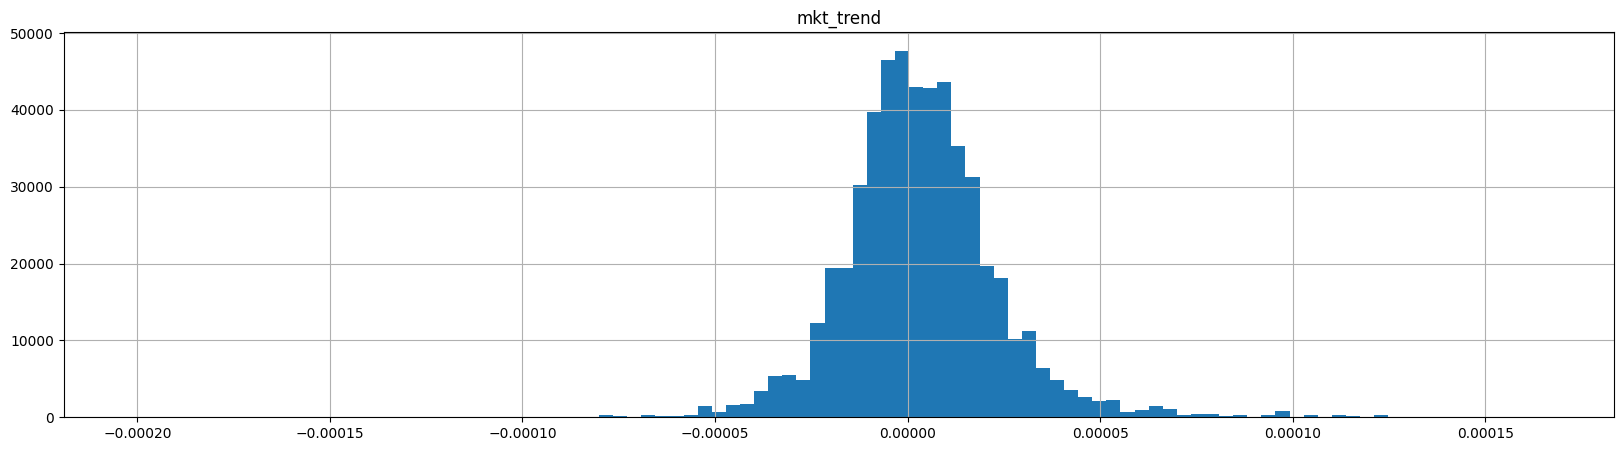

In [51]:
market_trend.hist(bins=100)

In [52]:
a = (train_df[Cols.vol_cols()] * market_trend.values).add_prefix("mkt_agr_")

In [53]:
a.join(train_df[["RET_1", "target", "SIGNED_VOLUME_17"]]).corr()

,mkt_agr_SIGNED_VOLUME_2,mkt_agr_SIGNED_VOLUME_3,mkt_agr_SIGNED_VOLUME_4,mkt_agr_SIGNED_VOLUME_5,mkt_agr_SIGNED_VOLUME_6,mkt_agr_SIGNED_VOLUME_7,mkt_agr_SIGNED_VOLUME_8,mkt_agr_SIGNED_VOLUME_9,mkt_agr_SIGNED_VOLUME_10,mkt_agr_SIGNED_VOLUME_11,...,mkt_agr_SIGNED_VOLUME_14,mkt_agr_SIGNED_VOLUME_15,mkt_agr_SIGNED_VOLUME_16,mkt_agr_SIGNED_VOLUME_17,mkt_agr_SIGNED_VOLUME_18,mkt_agr_SIGNED_VOLUME_19,mkt_agr_SIGNED_VOLUME_20,RET_1,target,SIGNED_VOLUME_17
mkt_agr_SIGNED_VOLUME_2,1.000000,0.679286,0.578849,0.517164,0.489150,0.448258,0.439621,0.404158,0.401514,0.379541,...,0.353311,0.349142,0.342733,0.317665,0.321730,0.309151,0.312995,0.047329,0.012971,0.036624
mkt_agr_SIGNED_VOLUME_3,0.679286,1.000000,0.699583,0.583884,0.545528,0.496659,0.471838,0.433450,0.421951,0.407786,...,0.370647,0.369071,0.354594,0.337748,0.341643,0.317796,0.316348,0.052122,0.013040,0.039576
mkt_agr_SIGNED_VOLUME_4,0.578849,0.699583,1.000000,0.689932,0.596397,0.528033,0.497429,0.450400,0.449356,0.427140,...,0.375021,0.373416,0.371251,0.344037,0.349951,0.334392,0.326933,0.052101,0.014828,0.045476
mkt_agr_SIGNED_VOLUME_5,0.517164,0.583884,0.689932,1.000000,0.699720,0.583527,0.528183,0.470440,0.473141,0.442041,...,0.388601,0.381114,0.371976,0.350027,0.346620,0.340462,0.334563,0.050716,0.017954,0.048585
mkt_agr_SIGNED_VOLUME_6,0.489150,0.545528,0.596397,0.699720,1.000000,0.683534,0.577420,0.502644,0.497491,0.464582,...,0.400116,0.393414,0.377099,0.346163,0.349294,0.339413,0.348643,0.053424,0.012712,0.049586
mkt_agr_SIGNED_VOLUME_7,0.448258,0.496659,0.528033,0.583527,0.683534,1.000000,0.677080,0.544639,0.523201,0.476919,...,0.405299,0.398586,0.392445,0.352272,0.345154,0.337154,0.333726,0.050143,0.016075,0.051787
mkt_agr_SIGNED_VOLUME_8,0.439621,0.471838,0.497429,0.528183,0.577420,0.677080,1.000000,0.641130,0.572927,0.508775,...,0.419386,0.406497,0.399383,0.361023,0.351465,0.338526,0.332688,0.046569,0.012463,0.052626
mkt_agr_SIGNED_VOLUME_9,0.404158,0.433450,0.450400,0.470440,0.502644,0.544639,0.641130,1.000000,0.649720,0.534517,...,0.412258,0.411343,0.385770,0.348983,0.353661,0.329872,0.329323,0.038901,0.015275,0.049456
mkt_agr_SIGNED_VOLUME_10,0.401514,0.421951,0.449356,0.473141,0.497491,0.523201,0.572927,0.649720,1.000000,0.666650,...,0.460173,0.432224,0.417258,0.377693,0.374799,0.360328,0.347540,0.049490,0.011417,0.066124
mkt_agr_SIGNED_VOLUME_11,0.379541,0.407786,0.427140,0.442041,0.464582,0.476919,0.508775,0.534517,0.666650,1.000000,...,0.490269,0.449545,0.431147,0.383003,0.380627,0.367746,0.361200,0.044010,0.011061,0.057495
